Step 1: Data Scraping from NAFDAC Greenbook Portal
We'll use Python's requests library to fetch the web page content and BeautifulSoup for parsing the HTML.

In [1]:
# Install necessary libraries
!pip install requests beautifulsoup4

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Define the URL of the NAFDAC Greenbook portal
url = 'https://greenbook.nafdac.gov.ng/'

print(f"Attempting to scrape data from: {url}")

try:
    # Send an HTTP GET request to the URL
    response = requests.get(url)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

    # Parse the HTML content of the page
    soup = BeautifulSoup(response.text, 'html.parser')

    print("Successfully fetched the page content. Now we need to inspect the HTML structure to extract specific data points like drug names, registration numbers, manufacturers, etc.")
    print("A snippet of the page title: ", soup.title.string if soup.title else "No title found")

except requests.exceptions.RequestException as e:
    print(f"An error occurred while fetching the URL: {e}")
    print("Please check your internet connection and ensure the URL is correct.")
    soup = None # Set soup to None if fetching fails
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    soup = None

Attempting to scrape data from: https://greenbook.nafdac.gov.ng/
Successfully fetched the page content. Now we need to inspect the HTML structure to extract specific data points like drug names, registration numbers, manufacturers, etc.
A snippet of the page title:   


In [3]:
import json
import urllib.parse
import requests # Ensure requests is imported
import pandas as pd # Ensure pandas is imported
import time # Import time for adding delays between requests

# The base URL for the AJAX request
ajax_base_url = 'https://greenbook.nafdac.gov.ng/'

# The query parameters provided by the user
query_params_str = "draw=1&columns%5B0%5D%5Bdata%5D=product_name&columns%5B0%5D%5Bname%5D=product_name&columns%5B0%5D%5Bsearchable%5D=true&columns%5B0%5D%5Borderable%5D=true&columns%5B0%5D%5Bsearch%5D%5Bvalue%5D=&columns%5B0%5D%5Bsearch%5D%5Bregex%5D=false&columns%5B1%5D%5Bdata%5D=ingredient.ingredient_name&columns%5B1%5D%5Bname%5D=ingredient.ingredient_name&columns%5B1%5D%5Bsearchable%5D=true&columns%5B1%5D%5Borderable%5D=true&columns%5B1%5D%5Bsearch%5D%5Bvalue%5D=&columns%5B1%5D%5Bsearch%5D%5Bregex%5D=false&columns%5B2%5D%5Bdata%5D=product_category.name&columns%5B2%5D%5Bname%5D=product_category.name&columns%5B2%5D%5Bsearchable%5D=true&columns%5B2%5D%5Borderable%5D=false&columns%5B2%5D%5Bsearch%5D%5Bvalue%5D=&columns%5B2%5D%5Bsearch%5D%5Bregex%5D=false&columns%5B3%5D%5Bdata%5D=product_category_id&columns%5B3%5D%5Bname%5D=product_category_id&columns%5B3%5D%5Bsearchable%5D=true&columns%5B3%5D%5Borderable%5D=true&columns%5B3%5D%5Bsearch%5D%5Bvalue%5D=&columns%5B3%5D%5Bsearch%5D%5Bregex%5D=false&columns%5B4%5D%5Bdata%5D=ingredient.synonym&columns%5B4%5D%5Bname%5D=ingredient.synonym&columns%5B4%5D%5Bsearchable%5D=true&columns%5B4%5D%5Borderable%5D=true&columns%5B4%5D%5Bsearch%5D%5Bvalue%5D=&columns%5B4%5D%5Bsearch%5D%5Bregex%5D=false&columns%5B5%5D%5Bdata%5D=NAFDAC&columns%5B5%5D%5Bname%5D=NAFDAC&columns%5B5%5D%5Bsearchable%5D=true&columns%5B5%5D%5Borderable%5D=true&columns%5B5%5D%5Bsearch%5D%5Bvalue%5D=&columns%5B5%5D%5Bsearch%5D%5Bregex%5D=false&columns%5B6%5D%5Bdata%5D=form.name&columns%5B6%5D%5Bname%5D=form.name&columns%5B6%5D%5Bsearchable%5D=true&columns%5B6%5D%5Borderable%5D=true&columns%5B6%5D%5Bsearch%5D%5Bvalue%5D=&columns%5B6%5D%5Bsearch%5D%5Bregex%5D=false&columns%5B7%5D%5Bdata%5D=route.name&columns%5B7%5D%5Bname%5D=route.name&columns%5B7%5D%5Bsearchable%5D=true&columns%5B7%5D%5Borderable%5D=true&columns%5B7%5D%5Bsearch%5D%5Bvalue%5D=&columns%5B7%5D%5Bsearch%5D%5Bregex%5D=false&columns%5B8%5D%5Bdata%5D=strength&columns%5B8%5D%5Bname%5D=strength&columns%5B8%5D%5Bsearchable%5D=true&columns%5B8%5D%5Borderable%5D=true&columns%5B8%5D%5Bsearch%5D%5Bvalue%5D=&columns%5B8%5D%5Bsearch%5D%5Bregex%5D=false&columns%5B9%5D%5Bdata%5D=applicant.name&columns%5B9%5D%5Bname%5D=applicant.name&columns%5B9%5D%5Bsearchable%5D=true&columns%5B9%5D%5Borderable%5D=true&columns%5B9%5D%5Bsearch%5D%5Bvalue%5D=&columns%5B9%5D%5Bsearch%5D%5Bregex%5D=false&columns%5B10%5D%5Bdata%5D=approval_date&columns%5B10%5D%5Bname%5D=approval_2date&columns%5B10%5D%5Bsearchable%5D=true&columns%5B10%5D%5Borderable%5D=true&columns%5B10%5D%5Bsearch%5D%5Bvalue%5D=&columns%5B10%5D%5Bsearch%5D%5Bregex%5D=false&columns%5B11%5D%5Bdata%5D=status&columns%5B11%5D%5Bname%5D=status&columns%5B11%5D%5Bsearchable%5D=true&columns%5B11%5D%5Borderable%5D=true&columns%5B11%5D%5Bsearch%5D%5Bvalue%5D=&columns%5B11%5D%5Bsearch%5D%5Bregex%5D=false&order%5B0%5D%5Bcolumn%5D=0&order%5B0%5D%5Bdir%5D=asc&start=0&length=10&search%5Bvalue%5D=&search%5Bregex%5D=false&search_ingredient=&_=1785984599617"

# Parse the query string into a dictionary
# Using a custom parsing function to handle potential multiple values for the same key correctly
def parse_query_string(query_string):
    params = urllib.parse.parse_qs(query_string)
    # Convert lists with single elements to single strings for easier manipulation
    for key, value in params.items():
        if isinstance(value, list) and len(value) == 1:
            params[key] = value[0]
    return params

query_params = parse_query_string(query_params_str)

# Modify pagination parameters
page_size = 100 # Number of records to fetch per request
query_params['length'] = str(page_size)

# Reset specific column search for product_category.name to empty (as it caused an SQL error previously)
query_params['columns[2][search][value]'] = ''

# Use the global search parameter 'search[value]' to search for 'Drug'
query_params['search[value]'] = 'Drug'
query_params['search[regex]'] = 'false' # Ensure regex is off for simple string search

# Define headers to mimic a browser's AJAX request
headers = {
    'Accept': 'application/json, text/javascript, */*; q=0.01',
    'X-Requested-With': 'XMLHttpRequest'
}

all_fetched_data = []
total_filtered_records = 0
current_draw = 1

print("Starting paginated data fetch...")

while True:
    query_params['start'] = str((current_draw - 1) * page_size)
    query_params['draw'] = str(current_draw)

    # Construct the full URL with modified parameters for the current page
    full_ajax_url = f"{ajax_base_url}?{urllib.parse.urlencode(query_params, doseq=True)}"

    print(f"Fetching page {current_draw} (start={query_params['start']}, length={page_size})...")

    try:
        response = requests.get(full_ajax_url, headers=headers)
        response.raise_for_status() # Raise an HTTPError for bad responses
        data = response.json()

        if not total_filtered_records:
            total_filtered_records = data.get('recordsFiltered', 0)
            print(f"Total records matching 'Drug' (globally): {total_filtered_records}")

        if 'data' in data and data['data']:
            all_fetched_data.extend(data['data'])
            print(f"Fetched {len(data['data'])} records for page {current_draw}.")
        else:
            print(f"No 'data' found in response for page {current_draw}. Breaking loop.")
            break

        # Break condition for the loop: if we have fetched all records or no more data is returned
        if len(all_fetched_data) >= total_filtered_records or not data['data']:
            print("All filtered records fetched or no more data available.")
            break

        current_draw += 1
        time.sleep(0.5) # Be respectful: add a small delay between requests

    except requests.exceptions.RequestException as e:
        print(f"An error occurred while fetching page {current_draw}: {e}")
        break
    except json.JSONDecodeError:
        print(f"Failed to decode JSON from response for page {current_draw}. Response content snippet (first 500 chars):")
        print(response.text[:500])
        break
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        break

if all_fetched_data:
    df_ajax_all = pd.DataFrame(all_fetched_data)
    print(f"\nSuccessfully collected a total of {len(df_ajax_all)} records matching the global 'Drug' search.")
    print("First 5 rows of the combined DataFrame:")
    display(df_ajax_all.head())
    print("DataFrame Info:")
    df_ajax_all.info()

    print("\nUnique product categories found in the collected data:")
    if 'category_name' in df_ajax_all.columns:
        unique_categories_all = df_ajax_all['category_name'].unique()
        for category in unique_categories_all:
            print(f"- {category}")

        # Now, perform client-side filtering for the 'Drug' category (adjust if the actual name is different)
        df_drugs_only = df_ajax_all[df_ajax_all['category_name'].str.contains('Drug', case=False, na=False)]
        print(f"\nFiltered for 'Drugs' category (client-side): {len(df_drugs_only)} records found.")
        if not df_drugs_only.empty:
            print("First 5 rows of the 'Drugs Only' DataFrame:")
            display(df_drugs_only.head())
            print("DataFrame Info for 'Drugs Only':")
            df_drugs_only.info()
        else:
            print("No records found for 'Drugs' category after client-side filtering. This might indicate the exact category name is different or no such categories were returned by the broad search.")
    else:
        print("The 'category_name' column was not found in the collected data. Cannot filter by category.")

else:
    print("No data was collected.")

Starting paginated data fetch...
Fetching page 1 (start=0, length=100)...
Total records matching 'Drug' (globally): 7511
Fetched 100 records for page 1.
Fetching page 2 (start=100, length=100)...
Fetched 100 records for page 2.
Fetching page 3 (start=200, length=100)...
Fetched 100 records for page 3.
Fetching page 4 (start=300, length=100)...
Fetched 100 records for page 4.
Fetching page 5 (start=400, length=100)...
Fetched 100 records for page 5.
Fetching page 6 (start=500, length=100)...
Fetched 100 records for page 6.
Fetching page 7 (start=600, length=100)...
Fetched 100 records for page 7.
Fetching page 8 (start=700, length=100)...
Fetched 100 records for page 8.
Fetching page 9 (start=800, length=100)...
Fetched 100 records for page 9.
Fetching page 10 (start=900, length=100)...
Fetched 100 records for page 10.
Fetching page 11 (start=1000, length=100)...
Fetched 100 records for page 11.
Fetching page 12 (start=1100, length=100)...
Fetched 100 records for page 12.
Fetching page 

,product_id,ingredient_id,manufacturer_id,product_name,form_id,strength,NAFDAC,product_category_id,marketing_category_id,applicant_id,...,applicant,route,product_category,category_name,ingredient_name,synonym,form_name,applicant_name,route_name,DT_RowIndex
0,9551,2137,1191,#Nipri Safe Hand Sanitizer,109,NA,A3-100630,5,5,1519,...,"{'id': 1519, 'name': 'Nipripharm Drug &amp; Re...","{'id': 46, 'name': 'NA', 'updated_at': '-00000...","{'id': 5, 'name': 'Medical devices', 'created_...",Medical devices,Hand Sanitizer,,NA,Nipripharm Drug &amp; Research Centre Lte/Gte,NA,1
1,9488,2132,1292,#Superfingers Non-Sterile Latex Examination Gl...,109,NA,A3-101325,5,5,1536,...,"{'id': 1536, 'name': 'Pdrugs Pharmacy Ltd', 'a...","{'id': 46, 'name': 'NA', 'updated_at': '-00000...","{'id': 5, 'name': 'Medical devices', 'created_...",Medical devices,Gloves,,NA,Pdrugs Pharmacy Ltd,NA,2
2,9524,2132,1292,#Superfingers Non-Sterile Latex Examination Gl...,109,NA,A3-101323,5,5,1536,...,"{'id': 1536, 'name': 'Pdrugs Pharmacy Ltd', 'a...","{'id': 46, 'name': 'NA', 'updated_at': '-00000...","{'id': 5, 'name': 'Medical devices', 'created_...",Medical devices,Gloves,,NA,Pdrugs Pharmacy Ltd,NA,3
3,9491,2132,1292,#Superfingers Non-Sterile Nitrile Examination ...,109,NA,A3-101324,5,5,1536,...,"{'id': 1536, 'name': 'Pdrugs Pharmacy Ltd', 'a...","{'id': 46, 'name': 'NA', 'updated_at': '-00000...","{'id': 5, 'name': 'Medical devices', 'created_...",Medical devices,Gloves,,NA,Pdrugs Pharmacy Ltd,NA,4
4,9297,2114,1094,*Primly Hospital And Home Urine Drug Test Kit,109,NA,A3-101318,5,5,1548,...,"{'id': 1548, 'name': 'Primly Services Limited'...","{'id': 46, 'name': 'NA', 'updated_at': '-00000...","{'id': 5, 'name': 'Medical devices', 'created_...",Medical devices,Test Kit,,NA,Primly Services Limited,NA,5


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7511 entries, 0 to 7510
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_id             7511 non-null   int64  
 1   ingredient_id          7511 non-null   int64  
 2   manufacturer_id        7511 non-null   int64  
 3   product_name           7511 non-null   object 
 4   form_id                7511 non-null   object 
 5   strength               7511 non-null   object 
 6   NAFDAC                 7511 non-null   object 
 7   product_category_id    7511 non-null   int64  
 8   marketing_category_id  7511 non-null   int64  
 9   applicant_id           7511 non-null   int64  
 10  approval_date          7511 non-null   object 
 11  expiry_date            7511 non-null   object 
 12  route_id               7511 non-null   int64  
 13  smpc                   7511 non-null   object 
 14  country_id             0 non-null      o

,product_id,ingredient_id,manufacturer_id,product_name,form_id,strength,NAFDAC,product_category_id,marketing_category_id,applicant_id,...,applicant,route,product_category,category_name,ingredient_name,synonym,form_name,applicant_name,route_name,DT_RowIndex
5,8875,638,5,10% Dextrose (500/1000 mL)**,114,10%,04-0858,1,1,154,...,"{'id': 154, 'name': 'Dana Pharmaceuticals Limi...","{'id': 12, 'name': 'Intravenous', 'updated_at'...","{'id': 1, 'name': 'Drugs', 'created_at': '-000...",Drugs,Glucose,Dextrose,Solution for infusion,Dana Pharmaceuticals Limited,Intravenous,6
6,12440,1625,6,10% DEXTROSE INFUSION $,114,10%,A11-0237,1,1,27,...,"{'id': 27, 'name': 'Fidson Healthcare PLC', 'a...","{'id': 12, 'name': 'Intravenous', 'updated_at'...","{'id': 1, 'name': 'Drugs', 'created_at': '-000...",Drugs,Dextrose Anhydrous,,Solution for infusion,Fidson Healthcare PLC,Intravenous,7
7,12441,475,239,1980 Azithromycin Tablets USP 500 mg $,1,500mg,A4-101970,1,1,1017,...,"{'id': 1017, 'name': '1980 Pharmaceutical Limi...","{'id': 1, 'name': 'Oral', 'updated_at': None, ...","{'id': 1, 'name': 'Drugs', 'created_at': '-000...",Drugs,Azithromycin (Azithromycin Dihydrate),,Tablet,1980 Pharmaceutical Limited,Oral,8
8,11525,41,57,1980 Pregabalin 150 mg Capsules**,2,150 mg,A4-101466,1,1,1017,...,"{'id': 1017, 'name': '1980 Pharmaceutical Limi...","{'id': 1, 'name': 'Oral', 'updated_at': None, ...","{'id': 1, 'name': 'Drugs', 'created_at': '-000...",Drugs,Pregabalin,,Capsule,1980 Pharmaceutical Limited,Oral,9
9,8380,1112,300,3-Xon Cream**,4,0.25 mg/g; 10 mg/g; 5000 IU/g,A4-101048,1,1,253,...,"{'id': 253, 'name': 'Onifam Laboratories Limit...","{'id': 21, 'name': 'Topical', 'updated_at': '-...","{'id': 1, 'name': 'Drugs', 'created_at': '-000...",Drugs,Clobetasol; Ketoconazole; Neomycin,,Cream,Onifam Laboratories Limited,Topical,10


DataFrame Info for 'Drugs Only':
<class 'pandas.core.frame.DataFrame'>
Index: 7503 entries, 5 to 7510
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_id             7503 non-null   int64  
 1   ingredient_id          7503 non-null   int64  
 2   manufacturer_id        7503 non-null   int64  
 3   product_name           7503 non-null   object 
 4   form_id                7503 non-null   object 
 5   strength               7503 non-null   object 
 6   NAFDAC                 7503 non-null   object 
 7   product_category_id    7503 non-null   int64  
 8   marketing_category_id  7503 non-null   int64  
 9   applicant_id           7503 non-null   int64  
 10  approval_date          7503 non-null   object 
 11  expiry_date            7503 non-null   object 
 12  route_id               7503 non-null   int64  
 13  smpc                   7503 non-null   object 
 14  country_id             0 non

Check for missing values

In [4]:
df_drugs_only.isnull().sum()

,0
product_id,0
ingredient_id,0
manufacturer_id,0
product_name,0
form_id,0
strength,0
NAFDAC,0
product_category_id,0
marketing_category_id,0
applicant_id,0


Clean the Genuine Nafdac Dataset

In [5]:
import pandas as pd
import re # Import the regular expression module

# Define the clean_nafdac function
def clean_nafdac(nafdac_string):
    if pd.isna(nafdac_string):
        return None
    # Remove non-alphanumeric characters and convert to uppercase
    return re.sub(r'[^a-zA-Z0-9]', '', str(nafdac_string)).upper()

columns_to_keep = [
    "NAFDAC",
    "product_name",
    "ingredient_name",
    "status",
    "strength",
    "form_name",
    "route_name",

    "applicant_name",
    "product_category",
    "approval_date",
    "expiry_date"
]

df_clean = df_drugs_only[
    [col for col in columns_to_keep if col in df_drugs_only.columns]
].copy()
df_clean["clean_nafdac"] = df_clean["NAFDAC"].apply(clean_nafdac)

# Clean the 'strength' column to remove spaces between numbers and units
df_clean['strength'] = df_clean['strength'].astype(str).str.replace(r'(\d+)\s*([a-zA-Z%]+)', r'\1\2', regex=True)

Inspect the cleaned Genuine Nafdac dataset

In [6]:
print("Shape:", df_clean.shape)

print("\nColumns:")
print(df_clean.columns.tolist())

print("\nFirst 5 rows:")
display(df_clean.head())

print("\nData types:")
print(df_clean.dtypes)

Shape: (7503, 12)

Columns:
['NAFDAC', 'product_name', 'ingredient_name', 'status', 'strength', 'form_name', 'route_name', 'applicant_name', 'product_category', 'approval_date', 'expiry_date', 'clean_nafdac']

First 5 rows:


,NAFDAC,product_name,ingredient_name,status,strength,form_name,route_name,applicant_name,product_category,approval_date,expiry_date,clean_nafdac
5,04-0858,10% Dextrose (500/1000 mL)**,Glucose,Inactive,10%,Solution for infusion,Intravenous,Dana Pharmaceuticals Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2021-08-03,2026-08-02,040858
6,A11-0237,10% DEXTROSE INFUSION $,Dextrose Anhydrous,Active,10%,Solution for infusion,Intravenous,Fidson Healthcare PLC,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2021-10-28,2026-10-27,A110237
7,A4-101970,1980 Azithromycin Tablets USP 500 mg $,Azithromycin (Azithromycin Dihydrate),Active,500mg,Tablet,Oral,1980 Pharmaceutical Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2026-02-24,2031-02-23,A4101970
8,A4-101466,1980 Pregabalin 150 mg Capsules**,Pregabalin,Active,150mg,Capsule,Oral,1980 Pharmaceutical Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2025-08-27,2030-08-26,A4101466
9,A4-101048,3-Xon Cream**,Clobetasol; Ketoconazole; Neomycin,Active,0.25mg/g; 10mg/g; 5000IU/g,Cream,Topical,Onifam Laboratories Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2024-09-25,2029-09-24,A4101048



Data types:
NAFDAC              object
product_name        object
ingredient_name     object
status              object
strength            object
form_name           object
route_name          object
applicant_name      object
product_category    object
approval_date       object
expiry_date         object
clean_nafdac        object
dtype: object


In [7]:
df_clean['product_name'] = df_clean['product_name'].str.replace(r'[-*#]+$', '', regex=True)
print("\nProduct names after removing trailing asterisks, dashes, and hashtags:")
display(df_clean.head())


Product names after removing trailing asterisks, dashes, and hashtags:


,NAFDAC,product_name,ingredient_name,status,strength,form_name,route_name,applicant_name,product_category,approval_date,expiry_date,clean_nafdac
5,04-0858,10% Dextrose (500/1000 mL),Glucose,Inactive,10%,Solution for infusion,Intravenous,Dana Pharmaceuticals Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2021-08-03,2026-08-02,040858
6,A11-0237,10% DEXTROSE INFUSION $,Dextrose Anhydrous,Active,10%,Solution for infusion,Intravenous,Fidson Healthcare PLC,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2021-10-28,2026-10-27,A110237
7,A4-101970,1980 Azithromycin Tablets USP 500 mg $,Azithromycin (Azithromycin Dihydrate),Active,500mg,Tablet,Oral,1980 Pharmaceutical Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2026-02-24,2031-02-23,A4101970
8,A4-101466,1980 Pregabalin 150 mg Capsules,Pregabalin,Active,150mg,Capsule,Oral,1980 Pharmaceutical Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2025-08-27,2030-08-26,A4101466
9,A4-101048,3-Xon Cream,Clobetasol; Ketoconazole; Neomycin,Active,0.25mg/g; 10mg/g; 5000IU/g,Cream,Topical,Onifam Laboratories Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2024-09-25,2029-09-24,A4101048


Examine the Genuine NAFDAC numbers

In [8]:
print("Sample cleaned NAFDAC numbers:")

display(
    df_clean[["NAFDAC", "clean_nafdac"]]
    .dropna()
    .head(20)
)

Sample cleaned NAFDAC numbers:


,NAFDAC,clean_nafdac
5,04-0858,040858
6,A11-0237,A110237
7,A4-101970,A4101970
8,A4-101466,A4101466
9,A4-101048,A4101048
10,B4-0452,B40452
11,A11-0325,A110325
12,04-1215,041215
13,04-0857,040857
14,A11-0236,A110236


In [9]:
print("\nLength distribution:")
print(
    df_clean["clean_nafdac"]
    .dropna()
    .str.len()
    .value_counts()
    .sort_index()
)


Length distribution:
clean_nafdac
0        3
2        1
3        1
5        3
6     5273
7      295
8     1343
9      583
15       1
Name: count, dtype: int64


Check Duplicate Genuine NAFDAC numbers

In [10]:
duplicate_count = df_clean["clean_nafdac"].duplicated().sum()

print("Number of duplicate cleaned NAFDAC numbers:", duplicate_count)
duplicates = df_clean[
    df_clean["clean_nafdac"].duplicated(keep=False)
].sort_values("clean_nafdac")

display(duplicates.head(20))

Number of duplicate cleaned NAFDAC numbers: 242


,NAFDAC,product_name,ingredient_name,status,strength,form_name,route_name,applicant_name,product_category,approval_date,expiry_date,clean_nafdac
733,,Avocomb Tablets 150/300 mg## (no NRN),Lamivudine; Zidovudine,Active,150mg; 300mg,Tablet,Oral,Ranbaxy Nigeria Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2023-03-28,2028-03-27,
3392,,HMA Ciprofloxacin,Ciprofloxacin,Active,200mg,Injection,Intravenous; Intramuscular,HMA Medical Ltd,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2023-07-06,2028-07-05,
3147,,Glamentin 625 mg Tablets,Amoxicillin (Amoxicillin Trihydrate); Clavulan...,Active,500mg; 125mg,Tablet,Oral,Globezza International Ltd,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2024-03-27,2029-03-26,
2499,04-0266,Emzolyn Expectorant,Diphenhydramine; Ammonium chloride; Sodium cit...,Active,14mg/5mL; 135mg/5mL; 57mg/5mL; 1.1mg/5mL,Syrup,Oral,Emzor Pharmaceutical Industries Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2024-05-29,2029-05-28,040266
2497,04-0266,Emzolyn 4 Way Syrup_,Dextromethorphan Hydrobromide; Phenylephrine H...,Active,10mg; 5mg; 2mg,Syrup,Oral,Emzor Pharmaceutical Industries Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2024-05-29,2029-05-28,040266
2515,04-0268,"Emzor Folic Acid Tablet## (duplicate, differen...",Folic acid,Active,5mg,Tablet,Oral,Emzor Pharmaceutical Industries Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2023-11-30,2028-11-29,040268
950,04-0268,"Bcosam Tablet## (duplicate, different product)",Vit A; Vit B1; Vit B2; Vit B6; Vit C; Vit D2; ...,Active,NA,Tablet,Oral,Sam Pharmaceutical Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2021-08-27,2026-08-26,040268
2450,04-0412,Emgyl 200 Tablets,Metronidazole,Active,200mg,Tablet,Oral,Emzor Pharmaceutical Industries Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2023-03-28,2028-03-27,040412
2449,04-0412,Emgyl 200 mg Tablet_,Metronidazole,Active,200mg,Tablet,Oral,Emzor Pharmaceutical Industries Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2025-05-27,2030-05-26,040412
7184,04-0764,Voltaren 75 mg Tablets,Diclofenac Sodium,Inactive,75mg,Tablet,Oral,Novartis Nigeria Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2021-05-27,2026-05-26,040764


Examins Status column

In [11]:
print(df_clean["status"].value_counts(dropna=False))

status
Active      5285
Inactive    2218
Name: count, dtype: int64


Check missing values

In [12]:
missing = df_clean.isnull().sum()
missing_percentage = (
    df_clean.isnull().mean() * 100
).sort_values(ascending=False)

display(missing_percentage)




print(missing)

,0
NAFDAC,0.0
product_name,0.0
ingredient_name,0.0
status,0.0
strength,0.0
form_name,0.0
route_name,0.0
applicant_name,0.0
product_category,0.0
approval_date,0.0


NAFDAC              0
product_name        0
ingredient_name     0
status              0
strength            0
form_name           0
route_name          0
applicant_name      0
product_category    0
approval_date       0
expiry_date         0
clean_nafdac        0
dtype: int64


Create a clean working copy

In [13]:
df_genuine = df_clean.copy()

print("Genuine dataset shape:", df_genuine.shape)

Genuine dataset shape: (7503, 12)


Decide which Greenbook records are genuine

In [14]:
df_genuine["status_clean"] = (
    df_genuine["status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print(df_genuine["status_clean"].value_counts())

df_genuine_active = df_genuine[
    df_genuine["status_clean"] == "active"
].copy()

print("Active genuine records:", len(df_genuine_active))

display(df_genuine_active.head())

status_clean
active      5285
inactive    2218
Name: count, dtype: int64
Active genuine records: 5285


,NAFDAC,product_name,ingredient_name,status,strength,form_name,route_name,applicant_name,product_category,approval_date,expiry_date,clean_nafdac,status_clean
6,A11-0237,10% DEXTROSE INFUSION $,Dextrose Anhydrous,Active,10%,Solution for infusion,Intravenous,Fidson Healthcare PLC,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2021-10-28,2026-10-27,A110237,active
7,A4-101970,1980 Azithromycin Tablets USP 500 mg $,Azithromycin (Azithromycin Dihydrate),Active,500mg,Tablet,Oral,1980 Pharmaceutical Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2026-02-24,2031-02-23,A4101970,active
8,A4-101466,1980 Pregabalin 150 mg Capsules,Pregabalin,Active,150mg,Capsule,Oral,1980 Pharmaceutical Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2025-08-27,2030-08-26,A4101466,active
9,A4-101048,3-Xon Cream,Clobetasol; Ketoconazole; Neomycin,Active,0.25mg/g; 10mg/g; 5000IU/g,Cream,Topical,Onifam Laboratories Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2024-09-25,2029-09-24,A4101048,active
10,B4-0452,3K Cream,Betamethasone; Clotrimazole; Neomycin sulfate,Active,0.05%; 1%; 0.5%,Cream,Topical,Kayhelt Pharma Limited,"{'id': 1, 'name': 'Drugs', 'created_at': '-000...",2021-10-28,2026-10-27,B40452,active


Create the Genuine label

In [15]:
df_genuine_active["label"] = "Genuine"

print(df_genuine_active["label"].value_counts())
display(
    df_genuine_active[
        ["NAFDAC", "clean_nafdac", "product_name", "status", "label"]
    ].head(10)
)

label
Genuine    5285
Name: count, dtype: int64


,NAFDAC,clean_nafdac,product_name,status,label
6,A11-0237,A110237,10% DEXTROSE INFUSION $,Active,Genuine
7,A4-101970,A4101970,1980 Azithromycin Tablets USP 500 mg $,Active,Genuine
8,A4-101466,A4101466,1980 Pregabalin 150 mg Capsules,Active,Genuine
9,A4-101048,A4101048,3-Xon Cream,Active,Genuine
10,B4-0452,B40452,3K Cream,Active,Genuine
11,A11-0325,A110325,4.3% Dextrose and Saline Infusion,Active,Genuine
12,04-1215,041215,4.3% Dextrose Saline (500 mL),Active,Genuine
14,A11-0236,A110236,5% Dextrose and Normal Saline Infusion,Active,Genuine
15,A11-0240,A110240,5% Dextrose Infusion,Active,Genuine
17,04-0859,040859,50% Dextrose (100 mL),Active,Genuine


Create the Look-up

In [16]:
df_greenbook = df_clean.copy()

df_greenbook["status_clean"] = (
    df_greenbook["status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

nafdac_lookup = (
    df_greenbook
    .dropna(subset=["clean_nafdac"])
    .drop_duplicates(subset=["clean_nafdac"])
    .set_index("clean_nafdac")
)

print("Unique NAFDAC numbers in lookup:", len(nafdac_lookup))

Unique NAFDAC numbers in lookup: 7261


Create a complete look-up function

In [17]:
def lookup_nafdac(nafdac_number, product_name=None, strength=None, route_name=None, ingredient_name=None, form_name=None, applicant_name=None, expiry_date=None):

    # Clean the submitted NAFDAC number
    cleaned = clean_nafdac(nafdac_number)

    # Check for empty/invalid input
    if cleaned is None or cleaned == "":
        return {
            "result": "INVALID_INPUT",
            "message": "No valid NAFDAC number was provided.",
            "record": None,
            "mismatches": []
        }

    # Search the complete Greenbook
    if cleaned not in nafdac_lookup.index:
        return {
            "result": "NOT_FOUND",
            "message": "NAFDAC number was not found in the Greenbook reference data.",
            "record": None,
            "mismatches": []
        }

    # Retrieve official record
    record = nafdac_lookup.loc[cleaned]
    mismatches = []

    # Perform additional checks if details are provided
    if product_name and product_name.strip().lower() != str(record["product_name"]).strip().lower():
        mismatches.append(f"Product Name mismatch: Provided '{product_name}' vs Greenbook '{record['product_name']}'")
    if strength and strength.strip().lower() != str(record["strength"]).strip().lower():
        mismatches.append(f"Strength mismatch: Provided '{strength}' vs Greenbook '{record['strength']}'")
    if route_name and route_name.strip().lower() != str(record["route_name"]).strip().lower():
        mismatches.append(f"Route Name mismatch: Provided '{route_name}' vs Greenbook '{record['route_name']}'")
    if ingredient_name and ingredient_name.strip().lower() != str(record["ingredient_name"]).strip().lower():
        mismatches.append(f"Ingredient Name mismatch: Provided '{ingredient_name}' vs Greenbook '{record['ingredient_name']}'")
    if form_name and form_name.strip().lower() != str(record["form_name"]).strip().lower():
        mismatches.append(f"Form Name mismatch: Provided '{form_name}' vs Greenbook '{record['form_name']}'")
    if applicant_name and applicant_name.strip().lower() != str(record["applicant_name"]).strip().lower():
        mismatches.append(f"Applicant Name mismatch: Provided '{applicant_name}' vs Greenbook '{record['applicant_name']}'")
    if expiry_date and str(expiry_date).strip().lower() != str(record["expiry_date"]).strip().lower(): # Compare as strings for simplicity
        mismatches.append(f"Expiry Date mismatch: Provided '{expiry_date}' vs Greenbook '{record['expiry_date']}'")

    # Get registration status
    status = str(record["status"]).strip().lower()

    if mismatches:
        return {
            "result": "FOUND_BUT_MISMATCH",
            "message": "NAFDAC number found but associated details do not match the Greenbook record.",
            "record": record,
            "mismatches": mismatches
        }
    elif status == "active":
        result = "FOUND_ACTIVE"
        message = "NAFDAC number was found and its registration status is active."

    elif status == "inactive":
        result = "FOUND_INACTIVE"
        message = "NAFDAC number was found, but its registration status is inactive."

    else:
        result = "FOUND_OTHER_STATUS"
        message = f"NAFDAC number was found with registration status: {record['status']}."

    return {
        "result": result,
        "message": message,
        "record": record,
        "mismatches": mismatches
    }


def test_nafdac(nafdac_number):
    result = lookup_nafdac(nafdac_number)

    print("Input NAFDAC:", nafdac_number)
    print("Result:", result["result"])
    print("Message:", result["message"])

    if result["record"] is not None:
        display(result["record"].to_frame().T)

    print("-" * 60)

Generating Synthetic NAFDAC Data

In [18]:
print("Total Greenbook records:", len(df_greenbook))
print("Unique NAFDAC numbers:", df_greenbook["clean_nafdac"].nunique())

print("\nStatus distribution:")
print(df_greenbook["status_clean"].value_counts(dropna=False))

Total Greenbook records: 7503
Unique NAFDAC numbers: 7261

Status distribution:
status_clean
active      5285
inactive    2218
Name: count, dtype: int64


Create a set of Genuine NAFDAC numbers

In [19]:
genuine_nafdac_set = set(
    df_greenbook["clean_nafdac"]
    .dropna()
    .astype(str)
)

print("Genuine NAFDAC numbers:", len(genuine_nafdac_set))

Genuine NAFDAC numbers: 7261


Identify the common NAFDAC Structure

In [20]:
def get_nafdac_structure(value):
    if pd.isna(value):
        return None

    value = str(value)

    structure = []

    for char in value:
        if char.isalpha():
            structure.append("L")
        elif char.isdigit():
            structure.append("D")

    return "".join(structure)


structure_counts = (
    df_greenbook["clean_nafdac"]
    .dropna()
    .apply(get_nafdac_structure)
    .value_counts()
)

display(structure_counts)

,count
clean_nafdac,
LDDDDD,4357
LDDDDDDD,1343
DDDDDD,915
LDDDDDDDD,582
LDDDDDD,293
,3
LDDDDDL,2
LLDDDD,1
LDDDD,1


In [21]:
import random
import string

def mutate_nafdac(nafdac_number):
    if not nafdac_number or not isinstance(nafdac_number, str):
        return None

    # Convert to list for mutability
    nafdac_list = list(nafdac_number)
    if not nafdac_list:
        return None

    # Choose a random position to mutate
    idx_to_mutate = random.randint(0, len(nafdac_list) - 1)

    # Determine the type of character at the position (letter or digit)
    original_char = nafdac_list[idx_to_mutate]
    if original_char.isalpha():
        new_char = random.choice(string.ascii_uppercase)
    elif original_char.isdigit():
        new_char = random.choice(string.digits)
    else:
        # For other characters (e.g., special symbols if they were kept), try to replace with alphanumeric
        new_char = random.choice(string.ascii_uppercase + string.digits)

    nafdac_list[idx_to_mutate] = new_char
    return "".join(nafdac_list)

def generate_fake_nafdac(structure, existing_numbers, max_attempts=1000):
    for _ in range(max_attempts):
        generated = ""

        for char in structure:
            if char == "L":
                generated += random.choice(string.ascii_uppercase)
            elif char == "D":
                generated += random.choice(string.digits)

        if generated not in existing_numbers:
            return generated

    return None  # fallback if not found

# Define available_structures before its first use
# It relies on 'structure_counts' which is available in the kernel state from cell 'HT62OOVT1aj8'
available_structures = [s for s in structure_counts.index.tolist() if s]

fake_numbers = set()  # use set to avoid duplicates

real_list = list(genuine_nafdac_set)

for _ in range(1200):  # slightly more to compensate for filtering

    method = random.choices(

        ["structure", "mutation", "invalid"],
        weights=[0.3, 0.6, 0.1]
    )[0]

    if method == "structure":
        structure = random.choice(available_structures)
        fake = generate_fake_nafdac(structure, genuine_nafdac_set)

    elif method == "mutation":
        real = random.choice(real_list)
        fake = mutate_nafdac(real)

    else:  # invalid
        fake = ''.join(random.choices(string.ascii_uppercase + string.digits, k=random.randint(4,10)))

    # ensure it's not real
    if fake and fake not in genuine_nafdac_set:
        fake_numbers.add(fake)

# convert back to list
fake_numbers = list(fake_numbers)[:1000]

Generate valid looking fake NAFDAC numbers

### `mutate_nafdac` Function

This function takes an existing NAFDAC number and introduces a small, random change to create a "fake" but plausible number. It works by:

1.  **Handling empty/invalid input**: Returns `None` if the input is not a valid string.
2.  **Random Character Selection**: Randomly selects one character in the input NAFDAC number.
3.  **Type-Preserving Mutation**: Replaces the selected character with another random character of the same type (letter for letter, digit for digit). If the character is neither, it replaces it with a random alphanumeric character.

The goal is to generate numbers that are structurally similar to genuine ones but are not actually registered, which is useful for testing validation systems.

Generate 3000 valid looking suspicious numbers

In [22]:
import random
import string
import time

synthetic_fake_numbers = []

available_structures = [s for s in structure_counts.index.tolist() if s] # Filter out empty structures
real_list = list(genuine_nafdac_set)

# ⏱️ Optional global timeout (in seconds)
MAX_RUNTIME = 30 # Increased to allow for more generations
start_time = time.time()

# 🔒 Safe wrappers to prevent infinite loops
def safe_mutate(real, max_attempts=50):
    for _ in range(max_attempts):
        fake = mutate_nafdac(real)
        if fake and fake not in genuine_nafdac_set:
            return fake
    return None

def safe_generate(structure, max_attempts=50):
    for _ in range(max_attempts):
        fake = generate_fake_nafdac(structure, genuine_nafdac_set)
        if fake and fake not in genuine_nafdac_set:
            return fake
    return None

for i in range(3000): # Changed from 1000 to 3000
    # ⏱️ Stop if taking too long
    if time.time() - start_time > MAX_RUNTIME:
        print("⛔ Timeout reached — stopping early")
        break

    # print(f"\nIteration {i}") # Commented out to reduce output

    method = random.choices(
        ["mutate", "structure", "invalid"],
        weights=[0.6, 0.3, 0.1]
    )[0]

    # print("Method:", method) # Commented out to reduce output

    fake = None

    if method == "mutate":
        real = random.choice(real_list)
        fake = safe_mutate(real)

    elif method == "structure":
        if not available_structures: # Handle case where all structures might have been filtered out
            print("⚠️ No valid structures available for generation.")
            continue
        structure = random.choice(available_structures)
        fake = safe_generate(structure)

    else:  # invalid
        fake = ''.join(
            random.choices(
                string.ascii_uppercase + string.digits,
                k=random.randint(4, 10)
            )
        )

    # ✅ Only add valid results
    if fake:
        synthetic_fake_numbers.append(fake)
    # else:
        # print("⚠️ Skipped due to generation failure") # Commented out to reduce output

print(f"\n✅ Generated {len(synthetic_fake_numbers)} fake numbers")


✅ Generated 2999 fake numbers


verify that none accidentally exist

In [23]:
fake_found_in_greenbook = set(synthetic_fake_numbers) & genuine_nafdac_set

if fake_found_in_greenbook:
    print(f"⚠️ Found {len(fake_found_in_greenbook)} overlaps!")
    print("Examples:", list(fake_found_in_greenbook)[:5])
else:
    print("✅ No synthetic numbers found in Greenbook")


✅ No synthetic numbers found in Greenbook


# Machine Learning Engineering Workflow for NAFDAC Detector

We will follow a structured Machine Learning Engineering process to build and evaluate the NAFDAC lookup/classifier system. The key steps are outlined below:

1.  **Data Preparation for Classification**: Combine genuine and synthetic fake NAFDAC numbers, create a unified dataset, and extract features that the classification model can use.
2.  **Data Exploration**: Understand the distributions and relationships within the combined dataset, focusing on features that differentiate genuine from fake.
3.  **Feature Engineering and Selection**: Develop and select the most impactful features from the NAFDAC strings for model training.
4.  **Data Splitting**: Divide the prepared dataset into training, validation (if necessary), and test sets to ensure robust model evaluation.
5.  **Model Selection and Training**: Choose and train a suitable machine learning classification model on the training data.
6.  **Model Evaluation and Testing**: Assess the model's performance on unseen test data using appropriate metrics and analyze its strengths and weaknesses.
7.  **Integration and Interactive Platform (MVP Frontend)**: Combine the `lookup_nafdac` function with the trained model into a user-friendly function that provides predictions and explanations for any NAFDAC number entry.

## 1. Data Preparation for Classification

This is the first crucial step in our ML pipeline. We need to create a single, labeled dataset that can be used to train and evaluate a classification model. This involves:

*   **Combining Genuine and Fake Data**: Merging the active genuine NAFDAC records (`df_genuine_active`) with the `synthetic_fake_numbers`.
*   **Labeling**: Clearly marking each record as 'Genuine' or 'Fake' (or 0/1).
*   **Feature Extraction**: Transforming the raw NAFDAC number strings into numerical features that a machine learning model can understand. This might include:
    *   Length of the NAFDAC string.
    *   Number/ratio of digits and letters.
    *   Presence of specific prefixes or patterns.
    *   One-hot encoding of common structures (e.g., 'LDDDDD').

### Combine Genuine and Fake Datasets

First, let's create a DataFrame for our synthetic fake numbers and assign them the 'Fake' label. Then, we'll combine this with our `df_genuine_active` DataFrame, ensuring consistent column names and adding the `true_label` column.

In [24]:
import pandas as pd

# Create a DataFrame for synthetic fake numbers
df_fake_eval = pd.DataFrame({
    'clean_nafdac': synthetic_fake_numbers
})
df_fake_eval['label'] = 'Fake'

print("df_fake_eval created. First 5 rows:")
display(df_fake_eval.head())
print(f"Total synthetic fake numbers: {len(df_fake_eval)}")

# Select relevant columns from df_genuine_active and add 'label' if not present (it should be from previous step)
df_genuine_for_eval = df_genuine_active[['clean_nafdac', 'label']].copy()

# Combine the genuine and fake datasets
df_combined = pd.concat([df_genuine_for_eval, df_fake_eval], ignore_index=True)

# Rename 'label' to 'true_label' for clarity in the combined dataset
df_combined.rename(columns={'label': 'true_label'}, inplace=True)

print("\nCombined evaluation dataset created. First 5 rows:")
display(df_combined.head())
print(f"Total records in combined dataset: {len(df_combined)}")
print("\nDistribution of true labels:")
display(df_combined['true_label'].value_counts())

df_fake_eval created. First 5 rows:


,clean_nafdac,label
0,B43427,Fake
1,040077,Fake
2,A4501307,Fake
3,049748,Fake
4,A4300969,Fake


Total synthetic fake numbers: 2999

Combined evaluation dataset created. First 5 rows:


,clean_nafdac,true_label
0,A110237,Genuine
1,A4101970,Genuine
2,A4101466,Genuine
3,A4101048,Genuine
4,B40452,Genuine


Total records in combined dataset: 8284

Distribution of true labels:


,count
true_label,
Genuine,5285
Fake,2999


### Feature Extraction from NAFDAC Numbers

Now we need to extract features from the `clean_nafdac` string that a machine learning model can process. These features will help the model learn patterns to distinguish genuine from fake numbers.

We'll extract the following features:
1.  **`nafdac_length`**: The total length of the cleaned NAFDAC number.
2.  **`num_digits`**: The count of digits in the NAFDAC number.
3.  **`num_letters`**: The count of letters in the NAFDAC number.
4.  **`digit_ratio`**: The ratio of digits to total length.
5.  **`letter_ratio`**: The ratio of letters to total length.
6.  **`has_prefix_A`**, **`has_prefix_B`**, etc.: Binary features indicating the presence of common NAFDAC prefixes (e.g., 'A', 'B', 'C', '0').
7.  **`structure_type`**: Categorical feature representing the sequence of letters (L) and digits (D), e.g., 'LDDDDD'. This will later be one-hot encoded.

In [25]:
import re

def extract_nafdac_features(df):
    df_features = df.copy()

    # 1. NAFDAC Length
    df_features['nafdac_length'] = df_features['clean_nafdac'].str.len()

    # 2. Number of Digits
    df_features['num_digits'] = df_features['clean_nafdac'].apply(lambda x: sum(c.isdigit() for c in x) if isinstance(x, str) else 0)

    # 3. Number of Letters
    df_features['num_letters'] = df_features['clean_nafdac'].apply(lambda x: sum(c.isalpha() for c in x) if isinstance(x, str) else 0)

    # 4. Digit Ratio
    df_features['digit_ratio'] = df_features['num_digits'] / df_features['nafdac_length']
    df_features['digit_ratio'] = df_features['digit_ratio'].fillna(0) # Handle division by zero for length 0 strings

    # 5. Letter Ratio
    df_features['letter_ratio'] = df_features['num_letters'] / df_features['nafdac_length']
    df_features['letter_ratio'] = df_features['letter_ratio'].fillna(0) # Handle division by zero

    # 6. Common Prefixes (example, can be extended)
    common_prefixes = ['A', 'B', 'C', '0']
    for prefix in common_prefixes:
        df_features[f'has_prefix_{prefix}'] = df_features['clean_nafdac'].str.startswith(prefix, na=False).astype(int)

    # 7. Structure Type (e.g., LDDDDD, DDDDDD)
    # Reuse the get_nafdac_structure function defined previously
    df_features['structure_type'] = df_features['clean_nafdac'].apply(get_nafdac_structure)

    return df_features

df_features = extract_nafdac_features(df_combined)

print("DataFrame with extracted features. First 5 rows:")
display(df_features.head())
print("\nInformation about the new feature columns:")
df_features[['nafdac_length', 'num_digits', 'num_letters', 'digit_ratio', 'letter_ratio', 'structure_type']].info()

DataFrame with extracted features. First 5 rows:


,clean_nafdac,true_label,nafdac_length,num_digits,num_letters,digit_ratio,letter_ratio,has_prefix_A,has_prefix_B,has_prefix_C,has_prefix_0,structure_type
0,A110237,Genuine,7,6,1,0.857143,0.142857,1,0,0,0,LDDDDDD
1,A4101970,Genuine,8,7,1,0.875000,0.125000,1,0,0,0,LDDDDDDD
2,A4101466,Genuine,8,7,1,0.875000,0.125000,1,0,0,0,LDDDDDDD
3,A4101048,Genuine,8,7,1,0.875000,0.125000,1,0,0,0,LDDDDDDD
4,B40452,Genuine,6,5,1,0.833333,0.166667,0,1,0,0,LDDDDD



Information about the new feature columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8284 entries, 0 to 8283
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   nafdac_length   8284 non-null   int64  
 1   num_digits      8284 non-null   int64  
 2   num_letters     8284 non-null   int64  
 3   digit_ratio     8284 non-null   float64
 4   letter_ratio    8284 non-null   float64
 5   structure_type  8284 non-null   object 
dtypes: float64(2), int64(3), object(1)
memory usage: 388.4+ KB


## 2. Data Exploration (ML Engineering Step: Data Exploration)

In this phase, we will analyze the characteristics of our dataset, focusing on the newly created features and their relationship with the `true_label`. This will help us understand the data better and inform our subsequent feature engineering and model selection steps.

We will explore:
*   The distribution of `true_label`.
*   Distributions of numerical features (`nafdac_length`, `num_digits`, `num_letters`, `digit_ratio`, `letter_ratio`).
*   Distribution of the categorical `structure_type` feature.
*   Correlation between features and the target label.

### Target Label Distribution

Let's check the balance of 'Genuine' vs. 'Fake' labels in our combined dataset.

True label value counts:


,count
true_label,
Genuine,5285
Fake,2999


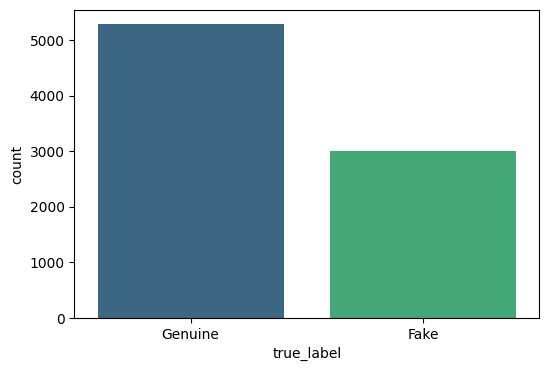

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map true_label to numerical values for plotting
df_features['true_label_numeric'] = df_features['true_label'].map({'Genuine': 1, 'Fake': 0})

plt.figure(figsize=(6, 4))
sns.countplot(
    x='true_label',
    data=df_features,
    hue='true_label',
    palette='viridis',
    legend=False
)

print("True label value counts:")
display(df_features['true_label'].value_counts())

### Explore Numerical Features

Let's visualize the distributions of our numerical features, separated by `true_label`, to see if there are clear distinctions.

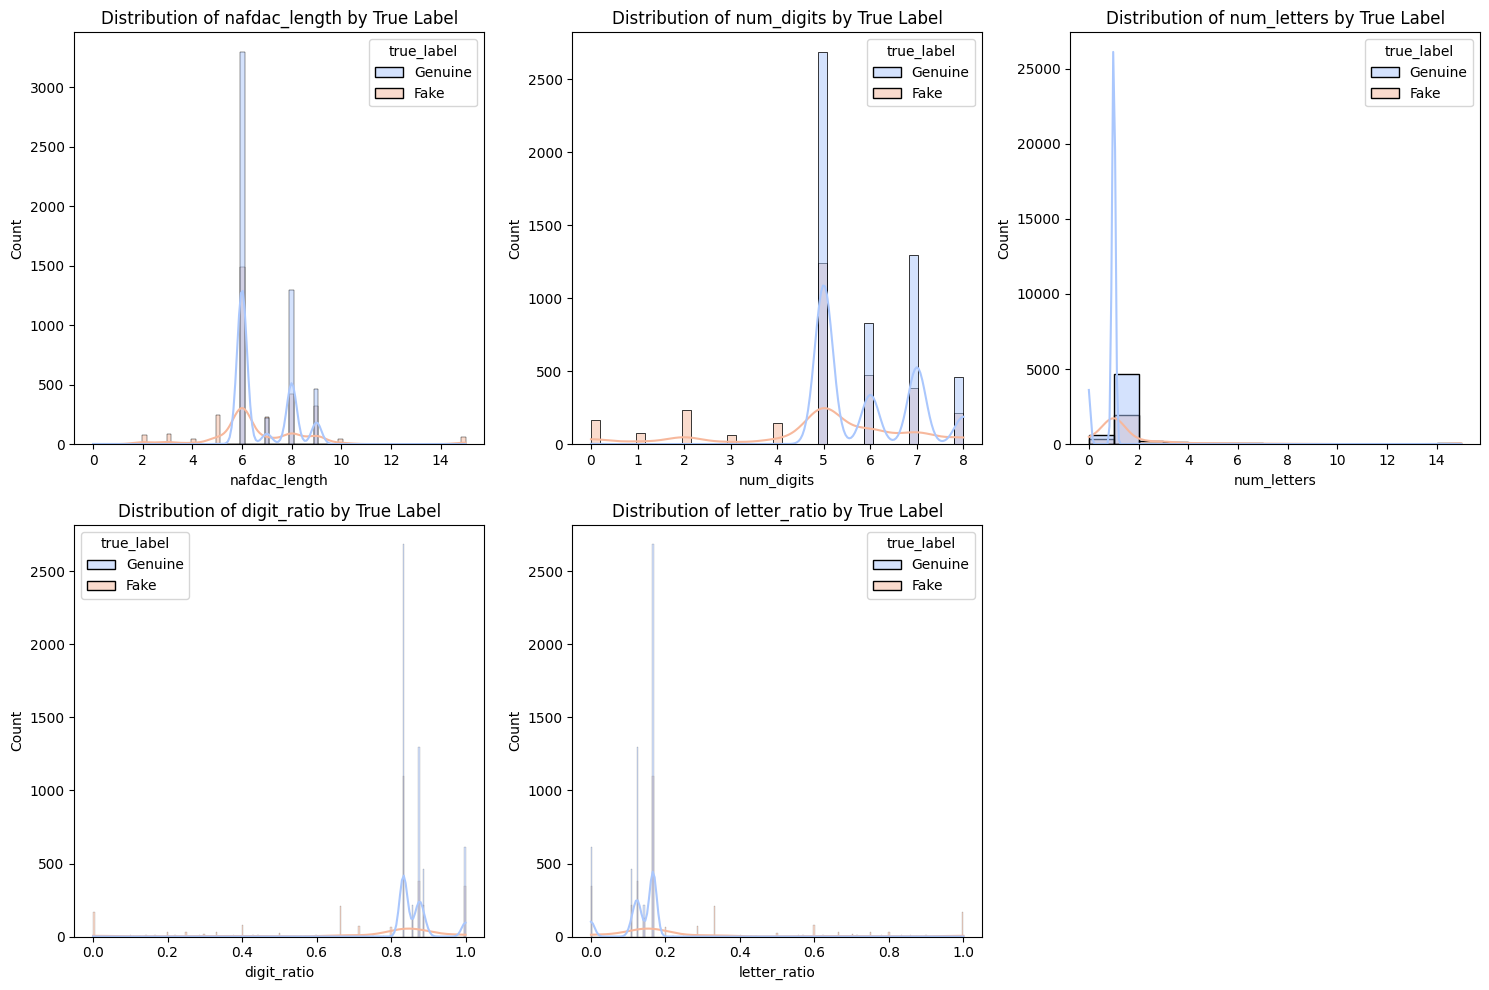

In [27]:
numerical_features = [
    'nafdac_length',
    'num_digits',
    'num_letters',
    'digit_ratio',
    'letter_ratio'
]

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(data=df_features, x=feature, hue='true_label', kde=True, palette='coolwarm')
    plt.title(f'Distribution of {feature} by True Label')
plt.tight_layout()
plt.show()

### Explore Categorical Feature: `structure_type`

The `structure_type` categorizes NAFDAC numbers by their pattern of letters (L) and digits (D). Let's see how genuine and fake numbers distribute across these structures.

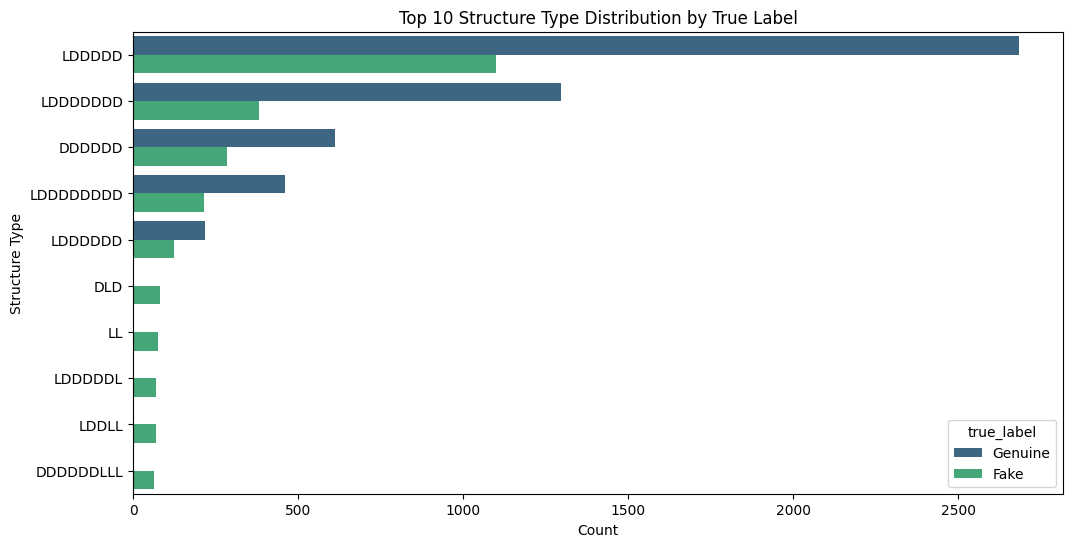

Structure type counts by true label:


true_label,Fake,Genuine
structure_type,,
LDDDDD,1099,2684
LDDDDDDD,383,1297
DDDDDD,284,612
LDDDDDDDD,215,461
LDDDDDD,124,218
,0,3
LDDDDDL,71,2
DLD,81,1
LDDDD,63,1


In [28]:
plt.figure(figsize=(12, 6))
sns.countplot(y='structure_type', hue='true_label', data=df_features, order=df_features['structure_type'].value_counts().index[:10], palette='viridis')
plt.title('Top 10 Structure Type Distribution by True Label')
plt.xlabel('Count')
plt.ylabel('Structure Type')
plt.show()

print("Structure type counts by true label:")
display(pd.crosstab(df_features['structure_type'], df_features['true_label']).sort_values(by='Genuine', ascending=False).head(10))

### Explore Prefix Features

Let's examine the `has_prefix_X` features to see if certain prefixes are more common in genuine or fake NAFDAC numbers.

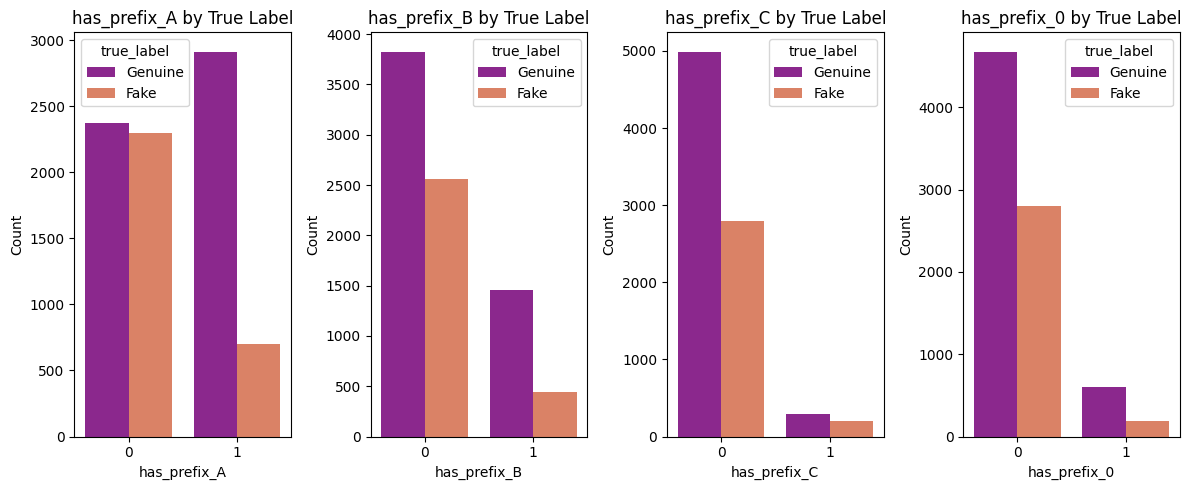

Prefix presence counts by true label:

has_prefix_A:


true_label,Fake,Genuine
has_prefix_A,,
0,2300,2372
1,699,2913



has_prefix_B:


true_label,Fake,Genuine
has_prefix_B,,
0,2558,3826
1,441,1459



has_prefix_C:


true_label,Fake,Genuine
has_prefix_C,,
0,2801,4992
1,198,293



has_prefix_0:


true_label,Fake,Genuine
has_prefix_0,,
0,2806,4677
1,193,608


In [29]:
prefix_features = [col for col in df_features.columns if col.startswith('has_prefix_')]

plt.figure(figsize=(12, 5))
for i, feature in enumerate(prefix_features):
    plt.subplot(1, len(prefix_features), i + 1)
    sns.countplot(x=feature, hue='true_label', data=df_features, palette='plasma')
    plt.title(f'{feature} by True Label')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("Prefix presence counts by true label:")
for feature in prefix_features:
    print(f"\n{feature}:")
    display(pd.crosstab(df_features[feature], df_features['true_label']))

##3. Feature Engineering and Selection (ML Engineering Step: Feature Engineering)

Based on our data exploration, several features appear to be good candidates for distinguishing genuine from fake NAFDAC numbers. In this step, we will:

Handle structure_type: This is a categorical feature, and we need to convert it into a numerical format that machine learning models can understand. One-hot encoding is a suitable method for this.
Prepare target variable: Convert the true_label ('Genuine', 'Fake') into a numerical format (e.g., 0 for 'Fake', 1 for 'Genuine').
Select final features: Based on the exploration, we will decide which features to include in our model.

## One-Hot Encode structure_type
The structure_type column contains string representations of NAFDAC number structures (e.g., 'LDDDDD', 'DDDDDD'). We need to convert these into numerical format using one-hot encoding. This will create new binary columns, one for each unique structure type.

In [30]:
# One-hot encode 'structure_type'
df_features_encoded = pd.get_dummies(df_features, columns=['structure_type'], prefix='structure')

print("DataFrame after one-hot encoding 'structure_type'. First 5 rows:")
display(df_features_encoded.head())
print(f"New number of columns: {df_features_encoded.shape[1]}")

DataFrame after one-hot encoding 'structure_type'. First 5 rows:


,clean_nafdac,true_label,nafdac_length,num_digits,num_letters,digit_ratio,letter_ratio,has_prefix_A,has_prefix_B,has_prefix_C,...,structure_LLLLLLDDL,structure_LLLLLLDDLL,structure_LLLLLLDLLL,structure_LLLLLLL,structure_LLLLLLLDL,structure_LLLLLLLL,structure_LLLLLLLLL,structure_LLLLLLLLLD,structure_LLLLLLLLLL,structure_LLLLLLLLLLLLLLL
0,A110237,Genuine,7,6,1,0.857143,0.142857,1,0,0,...,False,False,False,False,False,False,False,False,False,False
1,A4101970,Genuine,8,7,1,0.875000,0.125000,1,0,0,...,False,False,False,False,False,False,False,False,False,False
2,A4101466,Genuine,8,7,1,0.875000,0.125000,1,0,0,...,False,False,False,False,False,False,False,False,False,False
3,A4101048,Genuine,8,7,1,0.875000,0.125000,1,0,0,...,False,False,False,False,False,False,False,False,False,False
4,B40452,Genuine,6,5,1,0.833333,0.166667,0,1,0,...,False,False,False,False,False,False,False,False,False,False


New number of columns: 217


In [31]:
all_structure_types = df_features['structure_type'].unique().tolist()
print("All unique structure types captured for consistent encoding:")
print(all_structure_types)

All unique structure types captured for consistent encoding:
['LDDDDDD', 'LDDDDDDD', 'LDDDDD', 'DDDDDD', 'LDDDDDDDD', 'LLDDDD', '', 'LDDDDDL', 'LDDDD', 'DDDDD', 'LLLLLLLLLLLLLLL', 'DDDDDDLLL', 'LL', 'LDDLL', 'DLD', 'LLLLLDDLDL', 'DLDDLDLLL', 'LDLLLLDL', 'LLLLLLLL', 'LLLDL', 'LLLLDLL', 'LDLL', 'LDDLLLL', 'LLLD', 'DDLLLLLLLL', 'LLDLLLLLL', 'LLLLDL', 'LLDDDLDDLD', 'LLLLDDL', 'LDLLDDL', 'LLDLLLL', 'DDDDL', 'LLLL', 'DDDLLLLL', 'LLLLLLL', 'DDLL', 'LLLLDLLL', 'LLDL', 'DLLLLLL', 'DDLLLLD', 'LLDLLLDL', 'LLLLLLD', 'LDLDLL', 'LLLLDDDL', 'LDLDDLL', 'LLLLLL', 'LLLDLLLLL', 'LLDDLLLLD', 'DLDLLLLLLL', 'LLLLL', 'DLLDDLLL', 'DLDDDLDLL', 'DLLLLLLLLD', 'DDLLD', 'LLLDLDLLD', 'LLDDLLDL', 'LLLDLDL', 'LLLLLDLLLL', 'LLDLDLLLLL', 'LLLLD', 'LLDDLLD', 'LLLDLLDL', 'LDLLDLLLL', 'LLDLL', 'LLLLLDLL', 'LDLLLLLL', 'LLLLDDLLLL', 'DLLDLL', 'DLLLL', 'LLDLLLLLD', 'LLLLDDLLLD', 'LLDDLLL', 'LLLLDDLDD', 'DLLDDLLLL', 'LLLLLDLDLL', 'LLLLDLLDL', 'LLDLLL', 'LLLLDLD', 'LDDLLLLLD', 'LLLLDLLLD', 'DDLLLLLDL', 'LDLLLLLLDD', 'LLDDL', '

## Prepare Target Variable (y)
Our target variable is true_label. We need to convert it into a binary numerical format where 'Genuine' could be 1 and 'Fake' could be 0.

In [32]:
# Convert 'true_label' to numerical (0 or 1)
# Let 'Genuine' be 1 and 'Fake' be 0
df_features_encoded['target'] = df_features_encoded['true_label'].map({'Genuine': 1, 'Fake': 0})

print("Target variable distribution:")
display(df_features_encoded['target'].value_counts())

Target variable distribution:


,count
target,
1,5285
0,2999


##Final Feature Selection
We will now select the features that will be used for training our machine learning model. This includes the numerical features, prefix features, and the newly created one-hot encoded structure_type features. We will drop clean_nafdac, true_label, and true_label_numeric as they are either raw input or the target variable in a different format.

Our selected features are:

nafdac_length
num_digits
num_letters
digit_ratio
letter_ratio
has_prefix_A, has_prefix_B, has_prefix_C, has_prefix_0
All structure_type one-hot encoded columns

In [33]:
# Drop original NAFDAC string, original true_label, and the temporary numeric label
X = df_features_encoded.drop(columns=['clean_nafdac', 'true_label', 'true_label_numeric', 'target'])
y = df_features_encoded['target']

print("Selected features (X) shape:", X.shape)
print("Target variable (y) shape:", y.shape)
print("\nFirst 5 rows of features (X):")
display(X.head())
print("\nFirst 5 values of target (y):")
display(y.head())

Selected features (X) shape: (8284, 214)
Target variable (y) shape: (8284,)

First 5 rows of features (X):


,nafdac_length,num_digits,num_letters,digit_ratio,letter_ratio,has_prefix_A,has_prefix_B,has_prefix_C,has_prefix_0,structure_,...,structure_LLLLLLDDL,structure_LLLLLLDDLL,structure_LLLLLLDLLL,structure_LLLLLLL,structure_LLLLLLLDL,structure_LLLLLLLL,structure_LLLLLLLLL,structure_LLLLLLLLLD,structure_LLLLLLLLLL,structure_LLLLLLLLLLLLLLL
0,7,6,1,0.857143,0.142857,1,0,0,0,False,...,False,False,False,False,False,False,False,False,False,False
1,8,7,1,0.875000,0.125000,1,0,0,0,False,...,False,False,False,False,False,False,False,False,False,False
2,8,7,1,0.875000,0.125000,1,0,0,0,False,...,False,False,False,False,False,False,False,False,False,False
3,8,7,1,0.875000,0.125000,1,0,0,0,False,...,False,False,False,False,False,False,False,False,False,False
4,6,5,1,0.833333,0.166667,0,1,0,0,False,...,False,False,False,False,False,False,False,False,False,False



First 5 values of target (y):


,target
0,1
1,1
2,1
3,1
4,1


## 4. Data Splitting (ML Engineering Step: Data Splitting)

To evaluate our machine learning model effectively and ensure it generalizes well to new, unseen data, we must split our dataset into training and testing sets. The training set will be used to teach the model, and the testing set will be used to assess its performance.

We will perform a standard train-test split, typically using a 70/30 or 80/20 ratio. Given our dataset size and the importance of a robust evaluation, we'll aim for an 80/20 split, stratifying by the target variable to maintain the proportion of 'Genuine' and 'Fake' samples in both sets.

In [34]:
from sklearn.model_selection import train_test_split
import pandas as pd # Import pandas if not already imported in this cell

# Re-create df_features_encoded and related variables
# This assumes df_features is available from previous cells
# 1. One-hot encode 'structure_type'
df_features_encoded = pd.get_dummies(df_features, columns=['structure_type'], prefix='structure')

# 2. Convert 'true_label' to numerical (0 or 1)
# Let 'Genuine' be 1 and 'Fake' be 0
df_features_encoded['target'] = df_features_encoded['true_label'].map({'Genuine': 1, 'Fake': 0})

# Define our features (X) and target (y)
# X and y were prepared in the previous step, ensuring all feature columns are numerical and structure_type is one-hot encoded.
# Let's re-verify X and y to ensure they are correctly assigned after all previous steps.

X_final = df_features_encoded.drop(columns=['clean_nafdac', 'true_label', 'true_label_numeric', 'target'])
y_final = df_features_encoded['target']

# Perform the train-test split (80% train, 20% test)
# Stratify by y to ensure the same proportion of 'Genuine' and 'Fake' numbers in both train and test sets.
# random_state for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

print(f"Original dataset size: {len(X_final)}")
print(f"Training set size (X_train, y_train): {len(X_train)} samples")
print(f"Testing set size (X_test, y_test): {len(X_test)} samples")

print("\nDistribution of target in original dataset:")
display(y_final.value_counts(normalize=True))

print("\nDistribution of target in training set:")
display(y_train.value_counts(normalize=True))

print("\nDistribution of target in testing set:")
display(y_test.value_counts(normalize=True))

print("\nFirst 5 rows of X_train:")
display(X_train.head())

Original dataset size: 8284
Training set size (X_train, y_train): 6627 samples
Testing set size (X_test, y_test): 1657 samples

Distribution of target in original dataset:


,proportion
target,
1,0.637977
0,0.362023



Distribution of target in training set:


,proportion
target,
1,0.637996
0,0.362004



Distribution of target in testing set:


,proportion
target,
1,0.6379
0,0.3621



First 5 rows of X_train:


,nafdac_length,num_digits,num_letters,digit_ratio,letter_ratio,has_prefix_A,has_prefix_B,has_prefix_C,has_prefix_0,structure_,...,structure_LLLLLLDDL,structure_LLLLLLDDLL,structure_LLLLLLDLLL,structure_LLLLLLL,structure_LLLLLLLDL,structure_LLLLLLLL,structure_LLLLLLLLL,structure_LLLLLLLLLD,structure_LLLLLLLLLL,structure_LLLLLLLLLLLLLLL
623,8,7,1,0.875000,0.125000,1,0,0,0,False,...,False,False,False,False,False,False,False,False,False,False
6455,6,5,1,0.833333,0.166667,1,0,0,0,False,...,False,False,False,False,False,False,False,False,False,False
3626,6,5,1,0.833333,0.166667,0,1,0,0,False,...,False,False,False,False,False,False,False,False,False,False
2104,6,6,0,1.000000,0.000000,0,0,0,1,False,...,False,False,False,False,False,False,False,False,False,False
404,8,7,1,0.875000,0.125000,1,0,0,0,False,...,False,False,False,False,False,False,False,False,False,False


##5. Model Selection and Training (ML Engineering Step: Model Building)
Now that our data is prepared and split, we can select and train a machine learning model. For a binary classification task like distinguishing 'Genuine' from 'Fake' NAFDAC numbers, several models are suitable. We'll start with a robust and commonly used ensemble method: RandomForestClassifier. It handles various feature types well and is less prone to overfitting than some other models.

In this step, we will:

Initialize the model: Create an instance of the RandomForestClassifier.
Train the model: Fit the model to our training data (X_train, y_train).

In [35]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier
# We'll use default parameters for a first pass, with a random_state for reproducibility.
model = RandomForestClassifier(random_state=42)

# Train the model using the training data
print("Training the RandomForestClassifier...")
model.fit(X_train, y_train)

print("Model training complete!")
print(f"Model type: {type(model).__name__}")

Training the RandomForestClassifier...
Model training complete!
Model type: RandomForestClassifier


## 6. Model Evaluation and Testing (ML Engineering Step: Evaluation)

After training our model, it's essential to evaluate its performance on unseen data. This step will help us understand how well our model generalizes and identifies genuine versus fake NAFDAC numbers.

We will:
1.  **Make predictions** on the test set (`X_test`).
2.  **Calculate various classification metrics**:
    *   Accuracy
    *   Precision
    *   Recall
    *   F1-score
    *   Confusion Matrix
3.  **Visualize performance** through a confusion matrix and potentially a classification report.

Training the RandomForestClassifier...
Model training complete!

--- Model Evaluation Report ---
Accuracy: 0.8273989136994568

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.53      0.69       600
     Genuine       0.79      1.00      0.88      1057

    accuracy                           0.83      1657
   macro avg       0.89      0.76      0.78      1657
weighted avg       0.86      0.83      0.81      1657



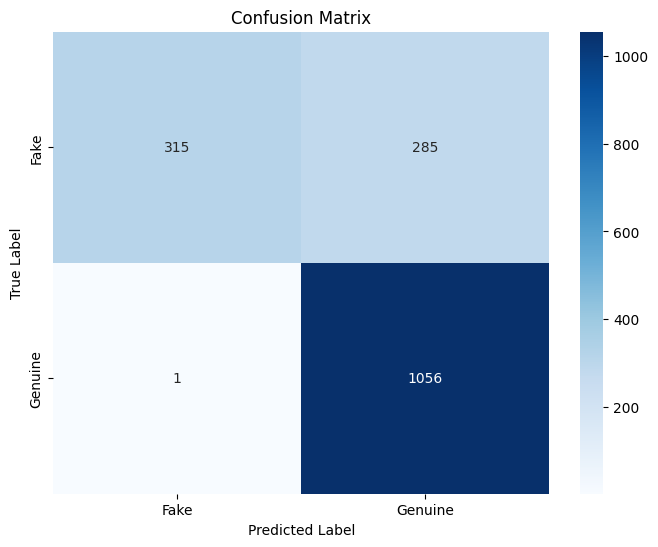

In [36]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Re-create df_features_encoded and related variables
# This assumes df_features is available from previous cells
# 1. One-hot encode 'structure_type'
df_features_encoded = pd.get_dummies(df_features, columns=['structure_type'], prefix='structure')

# 2. Store all unique structure types encountered during training
# This is crucial for consistent one-hot encoding during inference.
all_structure_types = df_features['structure_type'].unique().tolist()

# 3. Convert 'true_label' to numerical (0 or 1)
# Let 'Genuine' be 1 and 'Fake' be 0
df_features_encoded['target'] = df_features_encoded['true_label'].map({'Genuine': 1, 'Fake': 0})

# 4. Define our features (X) and target (y)
X_final = df_features_encoded.drop(columns=['clean_nafdac', 'true_label', 'true_label_numeric', 'target'])
y_final = df_features_encoded['target']

# 5. Perform the train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# 6. Initialize and train the RandomForestClassifier
model = RandomForestClassifier(random_state=42)
print("Training the RandomForestClassifier...")
model.fit(X_train, y_train)
print("Model training complete!")

# 1. Make predictions on the test set
y_pred = model.predict(X_test)

# 2. Evaluate the model
print("\n--- Model Evaluation Report ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Fake', 'Genuine']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Genuine'], yticklabels=['Fake', 'Genuine'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

##

# Interpretation of Results

*   **Accuracy**: Overall correctness of the model is approximately 0.82.
*   **Precision (for 'Genuine')**: Out of all predicted 'Genuine' NAFDACs, how many were actually 'Genuine'. The model has A high precision of 0.78  which means fewer false positives (i.e., less often flagging a fake as genuine).
*   **Recall (for 'Genuine')**: Out of all actual 'Genuine' NAFDACs, how many did the model correctly identify. The model has a perfect recall of 1.00 which means it correctly identified all Genuine Nafdac numbers (i.e.,True Positives).
*   **Precision (for 'Fake')**: Out of all predicted 'Fake' NAFDACs, how many were actually 'Fake'. The model has A high precision of 0.99 which  means the model is good at not wrongly flagging genuine as fake.
*   **Recall (for 'Fake')**: Out of all actual 'Fake' NAFDACs, how many did the model correctly identify. The model a low recall of 0.50 means the model may be weak at catching fake NAFDACs.
*   **F1-Score**: The harmonic mean of precision and recall, providing a balanced measure.
*   **Confusion Matrix**:
    *   `True Negatives (TN)` (top-left): Correctly predicted 'Fake' NAFDACs.
    *   `False Positives (FP)` (top-right): Predicted 'Genuine' but were actually 'Fake' (Type I error).
    *   `False Negatives (FN)` (bottom-left): Predicted 'Fake' but were actually 'Genuine' (Type II error).
    *   `True Positives (TP)` (bottom-right): Correctly predicted 'Genuine' NAFDACs.

After reviewing these metrics, we can assess the model's effectiveness and identify areas for potential improvement (e.g., through hyperparameter tuning, more advanced feature engineering, or different models).

In [37]:
print("df_features exists:", "df_features" in globals())

df_features exists: True


## 7. Integration and Interactive Platform (MVP Frontend)

This is the final step for our MVP, where we integrate our lookup system and the trained classification model into a single, user-friendly function. This function will simulate the interactive platform by taking a NAFDAC number as input and providing a verdict (Genuine, Suspicious, or Fake) along with an explanation.

Our approach will be:
1.  **First, use the `lookup_nafdac` function**: This is our primary source of truth, directly checking against the NAFDAC Greenbook data. If a NAFDAC is found, its status from the Greenbook (`Active`, `Inactive`, `Other`) will be prioritized.
2.  **If `lookup_nafdac` does NOT find the number**: We will then use our trained `RandomForestClassifier` model to predict if the number is 'Genuine' (likely a valid NAFDAC, but not in our scraped Greenbook data, possibly a new entry, or a 'False Negative' of the lookup) or 'Fake' (based on its features).
3.  **Provide clear explanations**: The output will include the verdict and a concise explanation.

In [38]:
import numpy as np

def predict_nafdac_status(nafdac_input, product_name=None, strength=None, route_name=None, ingredient_name=None, form_name=None, applicant_name=None, expiry_date=None):
    # Step 1: Use the lookup_nafdac function first, passing all available details
    lookup_result = lookup_nafdac(
        nafdac_input,
        product_name=product_name,
        strength=strength,
        route_name=route_name,
        ingredient_name=ingredient_name,
        form_name=form_name,
        applicant_name=applicant_name,
        expiry_date=expiry_date
    )

    # Initialize variables for model prediction
    model_prediction = None
    prediction_explanation = ""

    if lookup_result['result'] == "FOUND_ACTIVE":
        return {
            "verdict": "Genuine",
            "explanation": lookup_result['message']
        }
    elif lookup_result['result'] == "FOUND_INACTIVE":
        return {
            "verdict": "Suspicious",
            "explanation": lookup_result['message']
        }
    elif lookup_result['result'] == "FOUND_OTHER_STATUS":
        return {
            "verdict": "Suspicious",
            "explanation": lookup_result['message']
        }
    elif lookup_result['result'] == "FOUND_BUT_MISMATCH":
        return {
            "verdict": "Suspicious",
            "explanation": f"{lookup_result['message']} Mismatches: {'; '.join(lookup_result['mismatches'])}"
        }
    elif lookup_result['result'] == "INVALID_INPUT":
        # Handles cases where clean_nafdac returns None or ""
        return {
            "verdict": "Suspicious",
            "explanation": lookup_result['message']
        }
    else: # lookup_result['result'] == "NOT_FOUND"
        # Step 2: If not found in lookup, use the ML model.
        # At this point, the NAFDAC number has already been cleaned by lookup_nafdac
        # and is guaranteed not to be None or an empty string, as 'INVALID_INPUT'
        # would have been returned otherwise.
        cleaned_nafdac = clean_nafdac(nafdac_input)

        # Create a DataFrame for feature extraction for a single input
        single_nafdac_df = pd.DataFrame({'clean_nafdac': [cleaned_nafdac]})

        # Extract features using the same function used for training
        single_nafdac_features = extract_nafdac_features(single_nafdac_df)

        # Convert 'structure_type' to a categorical type with all known categories from training
        # This ensures pd.get_dummies creates consistent columns even for single-row inputs
        single_nafdac_features['structure_type'] = pd.Categorical(
            single_nafdac_features['structure_type'],
            categories=all_structure_types # This global variable needs to be defined
        )

        single_nafdac_encoded = pd.get_dummies(single_nafdac_features, columns=['structure_type'], prefix='structure')

        # Align columns with training data - add missing columns, remove extra ones
        missing_cols = set(X_final.columns) - set(single_nafdac_encoded.columns)
        for c in missing_cols:
            single_nafdac_encoded[c] = 0
        single_nafdac_encoded = single_nafdac_encoded[X_final.columns] # Ensure column order is the same

        # Predict using the trained model
        model_raw_prediction = model.predict(single_nafdac_encoded)
        model_proba = model.predict_proba(single_nafdac_encoded)[0]

        if model_raw_prediction[0] == 1: # Predicted as Genuine by the model
            # CRITICAL CHANGE: If not found in Greenbook, even if model predicts genuine, it's Suspicious
            model_prediction = "Suspicious"
            prediction_explanation = f"Not found in Greenbook. Machine learning model predicts structural 'Genuine' (Confidence: {model_proba[1]*100:.2f}%). This NAFDAC number is plausible but unregistered, and thus suspicious. Further verification is recommended."
        else: # Predicted as Fake by the model
            model_prediction = "Fake"
            prediction_explanation = f"Not found in Greenbook. Machine learning model predicts 'Fake' (Confidence: {model_proba[0]*100:.2f}%)."

        return {
            "verdict": model_prediction,
            "explanation": prediction_explanation
        }

# Example Usage:
print("\n--- Testing the Interactive Predictor ---")

# Test 1: Known Active Genuine (Matching Details)
print("Test 1: Known Active Genuine (Matching Details)")
active_record = df_genuine_active.iloc[0]
display(predict_nafdac_status(
    active_record['NAFDAC'],
    product_name=active_record['product_name'],
    strength=active_record['strength'],
    route_name=active_record['route_name'],
    ingredient_name=active_record['ingredient_name'],
    form_name=active_record['form_name'],
    applicant_name=active_record['applicant_name'],
    expiry_date=active_record['expiry_date']
))

# Test 2: Known Active Genuine (Mismatched Product Name)
print("\nTest 2: Known Active Genuine (Mismatched Product Name)")
active_record = df_genuine_active.iloc[0]
display(predict_nafdac_status(
    active_record['NAFDAC'],
    product_name="Wrong Product Name", # Mismatch here
    strength=active_record['strength'],
    route_name=active_record['route_name'],
    ingredient_name=active_record['ingredient_name'],
    form_name=active_record['form_name'],
    applicant_name=active_record['applicant_name'],
    expiry_date=active_record['expiry_date']
))

# Test 3: Known Active Genuine (Mismatched Expiry Date)
print("\nTest 3: Known Active Genuine (Mismatched Expiry Date)")
active_record = df_genuine_active.iloc[0]
display(predict_nafdac_status(
    active_record['NAFDAC'],
    product_name=active_record['product_name'],
    strength=active_record['strength'],
    route_name=active_record['route_name'],
    ingredient_name=active_record['ingredient_name'],
    form_name=active_record['form_name'],
    applicant_name=active_record['applicant_name'],
    expiry_date="2050-12-31" # Mismatch here
))

# Test 4: Known Inactive Genuine (if available, otherwise make one up to test logic)
# For example, let's pick one from df_clean that is inactive
df_genuine_inactive = df_clean[df_clean['status'].str.lower() == 'inactive']
if not df_genuine_inactive.empty:
    print("\nTest 4: Known Inactive Genuine")
    inactive_record = df_genuine_inactive.iloc[0]
    display(predict_nafdac_status(
        inactive_record['NAFDAC'],
        product_name=inactive_record['product_name'],
        strength=inactive_record['strength'],
        route_name=inactive_record['route_name'],
        ingredient_name=inactive_record['ingredient_name'],
        form_name=inactive_record['form_name'],
        applicant_name=inactive_record['applicant_name'],
        expiry_date=inactive_record['expiry_date']
    ))
else:
    print("\nTest 4: No inactive genuine NAFDACs found for testing lookup logic.")

# Test 5: Synthetic Fake NAFDAC number (should not be in lookup, model should predict fake)
print("\nTest 5: Synthetic Fake NAFDAC (model should predict Fake)")
display(predict_nafdac_status(synthetic_fake_numbers[0]))

# Test 6: Plausible NAFDAC (not in Greenbook, model might predict Genuine -> now Suspicious)
# (This often happens due to the model's high recall for 'Genuine')
print("\nTest 6: Plausible NAFDAC (not in Greenbook, model predicts Genuine -> now Suspicious)")
display(predict_nafdac_status("A4109999")) # A plausible format, likely not in greenbook

# Test 7: Completely Random Invalid NAFDAC (model should predict Fake or lookup invalid)
print("\nTest 7: Completely Random Invalid NAFDAC (model should predict Fake or lookup invalid)")
display(predict_nafdac_status("XYZ123ABC"))

# Test 8: Empty Input
print("\nTest 8: Empty Input")
display(predict_nafdac_status(""))


--- Testing the Interactive Predictor ---
Test 1: Known Active Genuine (Matching Details)


{'verdict': 'Genuine',
 'explanation': 'NAFDAC number was found and its registration status is active.'}


Test 2: Known Active Genuine (Mismatched Product Name)


{'verdict': 'Suspicious',
 'explanation': "NAFDAC number found but associated details do not match the Greenbook record. Mismatches: Product Name mismatch: Provided 'Wrong Product Name' vs Greenbook '10% DEXTROSE INFUSION $'"}


Test 3: Known Active Genuine (Mismatched Expiry Date)


...

{'verdict': 'Suspicious',
 'explanation': "Not found in Greenbook. Machine learning model predicts structural 'Genuine' (Confidence: 82.85%). This NAFDAC number is plausible but unregistered, and thus suspicious. Further verification is recommended."}


Test 7: Completely Random Invalid NAFDAC (model should predict Fake or lookup invalid)


{'verdict': 'Fake',
 'explanation': "Not found in Greenbook. Machine learning model predicts 'Fake' (Confidence: 100.00%)."}


Test 8: Empty Input


{'verdict': 'Suspicious',
 'explanation': 'No valid NAFDAC number was provided.'}

In [39]:
model
X_final
all_structure_types

['LDDDDDD',
 'LDDDDDDD',
 'LDDDDD',
 'DDDDDD',
 'LDDDDDDDD',
 'LLDDDD',
 '',
 'LDDDDDL',
 'LDDDD',
 'DDDDD',
 'LLLLLLLLLLLLLLL',
 'DDDDDDLLL',
 'LL',
 'LDDLL',
 'DLD',
 'LLLLLDDLDL',
 'DLDDLDLLL',
 'LDLLLLDL',
 'LLLLLLLL',
 'LLLDL',
 'LLLLDLL',
 'LDLL',
 'LDDLLLL',
 'LLLD',
 'DDLLLLLLLL',
 'LLDLLLLLL',
 'LLLLDL',
 'LLDDDLDDLD',
 'LLLLDDL',
 'LDLLDDL',
 'LLDLLLL',
 'DDDDL',
 'LLLL',
 'DDDLLLLL',
 'LLLLLLL',
 'DDLL',
 'LLLLDLLL',
 'LLDL',
 'DLLLLLL',
 'DDLLLLD',
 'LLDLLLDL',
 'LLLLLLD',
 'LDLDLL',
 'LLLLDDDL',
 'LDLDDLL',
 'LLLLLL',
 'LLLDLLLLL',
 'LLDDLLLLD',
 'DLDLLLLLLL',
 'LLLLL',
 'DLLDDLLL',
 'DLDDDLDLL',
 'DLLLLLLLLD',
 'DDLLD',
 'LLLDLDLLD',
 'LLDDLLDL',
 'LLLDLDL',
 'LLLLLDLLLL',
 'LLDLDLLLLL',
 'LLLLD',
 'LLDDLLD',
 'LLLDLLDL',
 'LDLLDLLLL',
 'LLDLL',
 'LLLLLDLL',
 'LDLLLLLL',
 'LLLLDDLLLL',
 'DLLDLL',
 'DLLLL',
 'LLDLLLLLD',
 'LLLLDDLLLD',
 'LLDDLLL',
 'LLLLDDLDD',
 'DLLDDLLLL',
 'LLLLLDLDLL',
 'LLLLDLLDL',
 'LLDLLL',
 'LLLLDLD',
 'LDDLLLLLD',
 'LLLLDLLLD',
 'DDLLLLLDL',
 'LDL

In [40]:
print(type(model))
print(X_final.shape)
print(len(all_structure_types))
print(df_greenbook.shape)
print(df_greenbook.columns.tolist())

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
(8284, 214)
205
(7503, 13)
['NAFDAC', 'product_name', 'ingredient_name', 'status', 'strength', 'form_name', 'route_name', 'applicant_name', 'product_category', 'approval_date', 'expiry_date', 'clean_nafdac', 'status_clean']


In [41]:
from pathlib import Path
import joblib

# Use the ARTIFACT_DIR pointing to Google Drive, as defined in cell QsI2ghVc48pK
PROJECT_DIR = Path("/content/drive/MyDrive/NAFDAC_Drug_Detector")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"

# Ensure the artifacts directory exists on Google Drive
ARTIFACT_DIR.mkdir(exist_ok=True, parents=True)

# -------------------------------------------------------
# 1. Save the trained machine-learning model
# -------------------------------------------------------

joblib.dump(
    model,
    ARTIFACT_DIR / "nafdac_model.joblib"
)

print("Model saved successfully to:", ARTIFACT_DIR / "nafdac_model.joblib")


# -------------------------------------------------------
# 2. Save the Greenbook lookup data
# -------------------------------------------------------

lookup_export = df_greenbook.copy()

# VERY IMPORTANT:
# Keep NAFDAC numbers as strings so leading zeros are preserved.
lookup_export["clean_nafdac"] = (
    lookup_export["clean_nafdac"]
    .fillna("")
    .astype(str)
)

lookup_export.to_csv(
    ARTIFACT_DIR / "greenbook_lookup.csv",
    index=False
)

print("Greenbook lookup saved successfully to:", ARTIFACT_DIR / "greenbook_lookup.csv")


# -------------------------------------------------------
# 3. Save feature metadata
# -------------------------------------------------------

metadata = {
    "feature_columns": list(X_final.columns),
    "all_structure_types": list(all_structure_types)
}

joblib.dump(
    metadata,
    ARTIFACT_DIR / "nafdac_metadata.joblib"
)

print("Feature metadata saved successfully to:", ARTIFACT_DIR / "nafdac_metadata.joblib")


# -------------------------------------------------------
# 4. Display what was created
# -------------------------------------------------------

print("\nExport complete!")
print("\nFiles created:")

for file in ARTIFACT_DIR.iterdir():
    print(" ", file)

Model saved successfully to: /content/drive/MyDrive/NAFDAC_Drug_Detector/artifacts/nafdac_model.joblib
Greenbook lookup saved successfully to: /content/drive/MyDrive/NAFDAC_Drug_Detector/artifacts/greenbook_lookup.csv
Feature metadata saved successfully to: /content/drive/MyDrive/NAFDAC_Drug_Detector/artifacts/nafdac_metadata.joblib

Export complete!

Files created:
  /content/drive/MyDrive/NAFDAC_Drug_Detector/artifacts/greenbook_lookup.csv
  /content/drive/MyDrive/NAFDAC_Drug_Detector/artifacts/nafdac_metadata.joblib
  /content/drive/MyDrive/NAFDAC_Drug_Detector/artifacts/nafdac_model.joblib


In [42]:
from pathlib import Path
import joblib
import pandas as pd

ARTIFACT_DIR = Path("/content/drive/MyDrive/NAFDAC_Drug_Detector/artifacts")

print("=== Files created ===")
for file in ARTIFACT_DIR.iterdir():
    print(f"{file.name}: {file.stat().st_size} bytes")

print("\n=== Loading verification ===")

# 1. Model
model_check = joblib.load(ARTIFACT_DIR / "nafdac_model.joblib")
print("Model:", type(model_check))
print("Model classes:", model_check.classes_)

# 2. Metadata
metadata_check = joblib.load(ARTIFACT_DIR / "nafdac_metadata.joblib")
print("\nMetadata keys:", metadata_check.keys())
print("Number of features:", len(metadata_check["feature_columns"]))
print("Number of structure types:", len(metadata_check["all_structure_types"]))

# 3. Greenbook
lookup_check = pd.read_csv(
    ARTIFACT_DIR / "greenbook_lookup.csv",
    dtype=str
)

print("\nGreenbook records:", len(lookup_check))
print("Greenbook columns:", len(lookup_check.columns))
print("clean_nafdac dtype:", lookup_check["clean_nafdac"].dtype)

print("\n=== Verification complete ===")

=== Files created ===
greenbook_lookup.csv: 2306915 bytes
nafdac_metadata.joblib: 6562 bytes
nafdac_model.joblib: 713721 bytes

=== Loading verification ===
Model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Model classes: [0 1]

Metadata keys: dict_keys(['feature_columns', 'all_structure_types'])
Number of features: 214
Number of structure types: 205

Greenbook records: 7503
Greenbook columns: 13
clean_nafdac dtype: object

=== Verification complete ===


In [43]:
from pathlib import Path

artifact_dir = Path("/content/drive/MyDrive/NAFDAC_Drug_Detector/artifacts")

for file in artifact_dir.iterdir():
    print(file.name, "→", file.stat().st_size, "bytes")

greenbook_lookup.csv → 2306915 bytes
nafdac_metadata.joblib → 6562 bytes
nafdac_model.joblib → 713721 bytes


In [44]:
from google.colab import drive
import os

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")
else:
    print("Google Drive is already mounted.")

Google Drive is already mounted.


In [45]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/NAFDAC_Drug_Detector"
)

ARTIFACT_DIR = PROJECT_DIR / "artifacts"

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project folder:", PROJECT_DIR)
print("Artifact folder:", ARTIFACT_DIR)

Project folder: /content/drive/MyDrive/NAFDAC_Drug_Detector
Artifact folder: /content/drive/MyDrive/NAFDAC_Drug_Detector/artifacts


In [46]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/NAFDAC_Drug_Detector")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"

print("Project exists:", PROJECT_DIR.exists())
print("Artifacts folder exists:", ARTIFACT_DIR.exists())

print("\nFiles in artifacts:")
if ARTIFACT_DIR.exists():
    for file in ARTIFACT_DIR.iterdir():
        print(file.name)

Project exists: True
Artifacts folder exists: True

Files in artifacts:
greenbook_lookup.csv
nafdac_metadata.joblib
nafdac_model.joblib


In [47]:
from pathlib import Path

app_path = Path(
    "/content/drive/MyDrive/NAFDAC_Drug_Detector/app.py"
)

print("app.py exists:", app_path.exists())

if app_path.exists():
    print("app.py size:", app_path.stat().st_size, "bytes")
else:
    print("app.py does not currently exist.")

app.py exists: True
app.py size: 12526 bytes


In [48]:
from pathlib import Path

app_path = Path(
    "/content/drive/MyDrive/NAFDAC_Drug_Detector/app.py"
)

print(app_path.read_text()[:500])


# Paste your complete Streamlit code here
import streamlit as st
import pandas as pd
import joblib
import re
from pathlib import Path

# --- Configuration: Point to Google Drive Artifacts --- #
# This path must match where the artifacts were saved on Google Drive
# Assumes Google Drive is mounted at /content/drive
ARTIFACT_DIR = Path("/content/drive/MyDrive/NAFDAC_Drug_Detector/artifacts")

# --- Load Artifacts (Model, Metadata, Lookup Data) --- #
@st.cache_resource
def load_artifacts():
    tr


In [49]:
!fuser -v 8501/tcp

In [51]:
import os

artifact_folder = "/content/drive/MyDrive/NAFDAC_Drug_Detector/artifacts"

print("Artifact files:")
for file in os.listdir(artifact_folder):
    print(file)

Artifact files:
greenbook_lookup.csv
nafdac_metadata.joblib
nafdac_model.joblib


In [52]:
import os

target_files = {
    "nafdac_metadata.joblib",
    "nafdac_model.joblib",
    "greenbook_lookup.csv"
}

found = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file in target_files:
            found.append(os.path.join(root, file))

print("Files found:")
if found:
    for path in found:
        print(path)
else:
    print("None of the three files were found in MyDrive.")

Files found:
/content/drive/MyDrive/NAFDAC_Drug_Detector/artifacts/greenbook_lookup.csv
/content/drive/MyDrive/NAFDAC_Drug_Detector/artifacts/nafdac_metadata.joblib
/content/drive/MyDrive/NAFDAC_Drug_Detector/artifacts/nafdac_model.joblib


## Streamlit Interface for NAFDAC Detector

This section generates the code for a Streamlit application that allows interactive verification of NAFDAC numbers using the trained machine learning model and the Greenbook lookup data. You can save this code as a `.py` file and run it using Streamlit.

In [53]:
%%writefile /content/drive/MyDrive/NAFDAC_Drug_Detector/app.py

import streamlit as st
import pandas as pd
import joblib
import re
from pathlib import Path

# --- Configuration: Point to Google Drive Artifacts --- #
# This path must match where the artifacts were saved on Google Drive
# Assumes Google Drive is mounted at /content/drive
ARTIFACT_DIR = Path("/content/drive/MyDrive/NAFDAC_Drug_Detector/artifacts")

# --- Load Artifacts (Model, Metadata, Lookup Data) --- #
@st.cache_resource
def load_artifacts():
    try:
        model = joblib.load(ARTIFACT_DIR / "nafdac_model.joblib")
        metadata = joblib.load(ARTIFACT_DIR / "nafdac_metadata.joblib")
        df_greenbook_lookup = pd.read_csv(ARTIFACT_DIR / "greenbook_lookup.csv", dtype=str)

        return model, metadata, df_greenbook_lookup
    except FileNotFoundError:
        st.error(f"Error: Artifacts not found at {ARTIFACT_DIR}. Please ensure the files are saved correctly.")
        st.stop()

model, metadata, df_greenbook_lookup = load_artifacts()

# Extract metadata for feature engineering
feature_columns = metadata["feature_columns"]
all_structure_types = metadata["all_structure_types"]

# Create the nafdac_lookup index from df_greenbook_lookup
# This recreates the lookup structure used in the notebook's `lookup_nafdac` function
df_greenbook_lookup["status_clean"] = df_greenbook_lookup["status"].astype(str).str.strip().str.lower()
nafdac_lookup = (
    df_greenbook_lookup
    .dropna(subset=["clean_nafdac"])
    .drop_duplicates(subset=["clean_nafdac"])
    .set_index("clean_nafdac")
)

# --- Helper Functions (copied from notebook) --- #
def clean_nafdac(nafdac_string):
    if pd.isna(nafdac_string):
        return None
    return re.sub(r'[^a-zA-Z0-9]', '', str(nafdac_string)).upper()

def get_nafdac_structure(value):
    if pd.isna(value):
        return None
    value = str(value)
    structure = []
    for char in value:
        if char.isalpha():
            structure.append("L")
        elif char.isdigit():
            structure.append("D")
    return "".join(structure)

def extract_nafdac_features(df):
    df_features = df.copy()
    df_features['nafdac_length'] = df_features['clean_nafdac'].str.len()
    df_features['num_digits'] = df_features['clean_nafdac'].apply(lambda x: sum(c.isdigit() for c in x) if isinstance(x, str) else 0)
    df_features['num_letters'] = df_features['clean_nafdac'].apply(lambda x: sum(c.isalpha() for c in x) if isinstance(x, str) else 0)
    df_features['digit_ratio'] = df_features['num_digits'] / df_features['nafdac_length']
    df_features['digit_ratio'] = df_features['digit_ratio'].fillna(0)
    df_features['letter_ratio'] = df_features['num_letters'] / df_features['nafdac_length']
    df_features['letter_ratio'] = df_features['letter_ratio'].fillna(0)

    common_prefixes = ['A', 'B', 'C', '0']
    for prefix in common_prefixes:
        df_features[f'has_prefix_{prefix}'] = df_features['clean_nafdac'].str.startswith(prefix, na=False).astype(int)

    df_features['structure_type'] = df_features['clean_nafdac'].apply(get_nafdac_structure)
    return df_features

def lookup_nafdac(nafdac_number, product_name=None, strength=None, route_name=None, ingredient_name=None, form_name=None, applicant_name=None, expiry_date=None):
    cleaned = clean_nafdac(nafdac_number)
    if cleaned is None or cleaned == "":
        return {
            "result": "INVALID_INPUT",
            "message": "No valid NAFDAC number was provided.",
            "record": None,
            "mismatches": []
        }
    if cleaned not in nafdac_lookup.index:
        return {
            "result": "NOT_FOUND",
            "message": "NAFDAC number was not found in the Greenbook reference data.",
            "record": None,
            "mismatches": []
        }

    record = nafdac_lookup.loc[cleaned]
    mismatches = []

    # Convert all inputs to string and lower for comparison, handling None
    def safe_lower(val): return str(val).strip().lower() if val is not None else ''

    if product_name and safe_lower(product_name) != safe_lower(record["product_name"]):
        mismatches.append(f"Product Name mismatch: Provided '{product_name}' vs Greenbook '{record['product_name']}'")
    if strength and safe_lower(strength) != safe_lower(record["strength"]):
        mismatches.append(f"Strength mismatch: Provided '{strength}' vs Greenbook '{record['strength']}'")
    if route_name and safe_lower(route_name) != safe_lower(record["route_name"]):
        mismatches.append(f"Route Name mismatch: Provided '{route_name}' vs Greenbook '{record['route_name']}'")
    if ingredient_name and safe_lower(ingredient_name) != safe_lower(record["ingredient_name"]):
        mismatches.append(f"Ingredient Name mismatch: Provided '{ingredient_name}' vs Greenbook '{record['ingredient_name']}'")
    if form_name and safe_lower(form_name) != safe_lower(record["form_name"]):
        mismatches.append(f"Form Name mismatch: Provided '{form_name}' vs Greenbook '{record['form_name']}'")
    if applicant_name and safe_lower(applicant_name) != safe_lower(record["applicant_name"]):
        mismatches.append(f"Applicant Name mismatch: Provided '{applicant_name}' vs Greenbook '{record['applicant_name']}'")
    if expiry_date and safe_lower(expiry_date) != safe_lower(record["expiry_date"]):
        mismatches.append(f"Expiry Date mismatch: Provided '{expiry_date}' vs Greenbook '{record['expiry_date']}'")

    status = safe_lower(record["status"])

    if mismatches:
        return {
            "result": "FOUND_BUT_MISMATCH",
            "message": "NAFDAC number found but associated details do not match the Greenbook record.",
            "record": record,
            "mismatches": mismatches
        }
    elif status == "active":
        return {
            "result": "FOUND_ACTIVE",
            "message": "NAFDAC number was found and its registration status is active.",
            "record": record,
            "mismatches": mismatches
        }
    elif status == "inactive":
        return {
            "result": "FOUND_INACTIVE",
            "message": "NAFDAC number was found, but its registration status is inactive.",
            "record": record,
            "mismatches": mismatches
        }
    else:
        return {
            "result": "FOUND_OTHER_STATUS",
            "message": f"NAFDAC number was found with registration status: {record['status']}.",
            "record": record,
            "mismatches": mismatches
        }

def predict_nafdac_status_ml(nafdac_input, product_name=None, strength=None, route_name=None, ingredient_name=None, form_name=None, applicant_name=None, expiry_date=None):
    # Step 1: Use the lookup_nafdac function first, passing all available details
    lookup_result = lookup_nafdac(
        nafdac_input,
        product_name=product_name,
        strength=strength,
        route_name=route_name,
        ingredient_name=ingredient_name,
        form_name=form_name,
        applicant_name=applicant_name,
        expiry_date=expiry_date
    )

    if lookup_result['result'] == "FOUND_ACTIVE":
        return {"verdict": "Genuine", "explanation": lookup_result['message']}
    elif lookup_result['result'] == "FOUND_INACTIVE":
        return {"verdict": "Suspicious", "explanation": lookup_result['message']}
    elif lookup_result['result'] == "FOUND_OTHER_STATUS":
        return {"verdict": "Suspicious", "explanation": lookup_result['message']}
    elif lookup_result['result'] == "FOUND_BUT_MISMATCH":
        return {"verdict": "Suspicious", "explanation": f"{lookup_result['message']} Mismatches: {'; '.join(lookup_result['mismatches'])}"}
    elif lookup_result['result'] == "INVALID_INPUT":
        return {"verdict": "Suspicious", "explanation": lookup_result['message']}
    else: # lookup_result['result'] == "NOT_FOUND"
        cleaned_nafdac = clean_nafdac(nafdac_input)

        if not cleaned_nafdac:
             return {"verdict": "Suspicious", "explanation": "Invalid or empty NAFDAC input for ML prediction."}

        single_nafdac_df = pd.DataFrame({'clean_nafdac': [cleaned_nafdac]})
        single_nafdac_features = extract_nafdac_features(single_nafdac_df)

        # Ensure structure_type is categorical with all known categories
        single_nafdac_features['structure_type'] = pd.Categorical(
            single_nafdac_features['structure_type'],
            categories=all_structure_types
        )

        single_nafdac_encoded = pd.get_dummies(single_nafdac_features, columns=['structure_type'], prefix='structure')

        # Align columns with training data
        # X_final needs to be globally available or re-created here from metadata
        # For simplicity, assuming X_final.columns is known from metadata['feature_columns']
        missing_cols = set(feature_columns) - set(single_nafdac_encoded.columns)
        for c in missing_cols:
            single_nafdac_encoded[c] = 0
        single_nafdac_encoded = single_nafdac_encoded[feature_columns] # Ensure column order

        model_raw_prediction = model.predict(single_nafdac_encoded)
        model_proba = model.predict_proba(single_nafdac_encoded)[0]

        if model_raw_prediction[0] == 1: # Predicted as Genuine by the model
            return {"verdict": "Suspicious", "explanation": f"Not found in Greenbook. ML model predicts structural 'Genuine' (Confidence: {model_proba[1]*100:.2f}%). This NAFDAC number is plausible but unregistered, and thus suspicious. Further verification is recommended."}
        else: # Predicted as Fake by the model
            return {"verdict": "Fake", "explanation": f"Not found in Greenbook. ML model predicts 'Fake' (Confidence: {model_proba[0]*100:.2f}%)."}

# --- Streamlit UI --- #
st.set_page_config(page_title="NAFDAC Number Verification", layout="centered")
st.title("NAFDAC Number Drug Verification System")
st.markdown("---")

st.markdown(
    "Enter a NAFDAC number and optional details to verify its status against the Greenbook and a Machine Learning model."
)

# Initialize session state for input widget values if not already present
if 'nafdac_input_widget' not in st.session_state:
    st.session_state.nafdac_input_widget = ""
if 'product_name_widget' not in st.session_state:
    st.session_state.product_name_widget = ""
if 'strength_widget' not in st.session_state:
    st.session_state.strength_widget = ""
if 'route_name_widget' not in st.session_state:
    st.session_state.route_name_widget = ""
if 'ingredient_name_widget' not in st.session_state:
    st.session_state.ingredient_name_widget = ""
if 'form_name_widget' not in st.session_state:
    st.session_state.form_name_widget = ""
if 'applicant_name_widget' not in st.session_state:
    st.session_state.applicant_name_widget = ""
if 'expiry_date_widget' not in st.session_state:
    st.session_state.expiry_date_widget = ""


def clear_all_inputs():
    st.session_state.nafdac_input_widget = ""
    st.session_state.product_name_widget = ""
    st.session_state.strength_widget = ""
    st.session_state.route_name_widget = ""
    st.session_state.ingredient_name_widget = ""
    st.session_state.form_name_widget = ""
    st.session_state.applicant_name_widget = ""
    st.session_state.expiry_date_widget = ""


with st.form("nafdac_form"):
    st.subheader("Required Field:")
    nafdac_input = st.text_input("NAFDAC Number", placeholder="e.g., A4-0001",
                                 key="nafdac_input_widget")

    st.subheader("Optional Details for Enhanced Verification:")
    col1, col2 = st.columns(2)
    with col1:
        product_name = st.text_input("Product Name", placeholder="e.g., Paracetamol Tablet",
                                     key="product_name_widget")
        strength = st.text_input("Strength", placeholder="e.g., 500mg",
                                 key="strength_widget")
        route_name = st.text_input("Route Name", placeholder="e.g., Oral",
                                   key="route_name_widget")
        ingredient_name = st.text_input("Ingredient Name", placeholder="e.g., Paracetamol",
                                        key="ingredient_name_widget")
    with col2:
        form_name = st.text_input("Form Name", placeholder="e.g., Tablet",
                                  key="form_name_widget")
        applicant_name = st.text_input("Applicant Name", placeholder="e.g., ABC Pharma Ltd",
                                      key="applicant_name_widget")
        expiry_date = st.text_input("Expiry Date (YYYY-MM-DD)", placeholder="e.g., 2025-12-31",
                                    key="expiry_date_widget")

    col_buttons = st.columns(2)
    with col_buttons[0]:
        submitted = st.form_submit_button("Verify NAFDAC Number")
    with col_buttons[1]:
        cleared = st.form_submit_button("Clear", on_click=clear_all_inputs)

    if submitted:
        if not nafdac_input:
            st.error("Please enter a NAFDAC Number to proceed.")
        else:
            # Convert empty strings from text_input to None for the prediction function
            def convert_empty_to_none(s): return s if s else None

            result = predict_nafdac_status_ml(
                nafdac_input,
                product_name=convert_empty_to_none(product_name),
                strength=convert_empty_to_none(strength),
                route_name=convert_empty_to_none(route_name),
                ingredient_name=convert_empty_to_none(ingredient_name),
                form_name=convert_empty_to_none(form_name),
                applicant_name=convert_empty_to_none(applicant_name),
                expiry_date=convert_empty_to_none(expiry_date)
            )

            st.markdown("### Verification Result")
            if result["verdict"] == "Genuine":
                st.success(f"**Verdict:** {result['verdict']}")
                st.write(result["explanation"])
            elif result["verdict"] == "Suspicious":
                st.warning(f"**Verdict:** {result['verdict']}")
                st.write(result["explanation"])
            else: # Fake
                st.error(f"**Verdict:** {result['verdict']}")
                st.write(result["explanation"])

st.markdown("--- ")
st.info("**Note:** This system combines a direct Greenbook lookup with a Machine Learning model. If a number is not found in the Greenbook but appears structurally genuine, it will be flagged as 'Suspicious' for further manual verification.")

Overwriting /content/drive/MyDrive/NAFDAC_Drug_Detector/app.py


In [54]:
!streamlit run /content/drive/MyDrive/NAFDAC_Drug_Detector/app.py



2026-08-20 08:34:02.894 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.182.233.97:8501

  Stopping...


In [55]:
print('Stopping any existing Streamlit processes...')
!fuser -k 8501/tcp
print('Existing Streamlit processes stopped.')

Stopping any existing Streamlit processes...
Existing Streamlit processes stopped.


In [56]:
!pip install -q streamlit

In [57]:
!streamlit --version

Streamlit, version 1.62.0


In [58]:
# The app.py was already overwritten with the clear button logic in the previous turn.
# Now, let's restart the Streamlit app with the updated code.
!rm -f /content/streamlit.log

!streamlit run /content/drive/MyDrive/NAFDAC_Drug_Detector/app.py \
  --server.port 8501 \
  --server.address 0.0.0.0 \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  --browser.gatherUsageStats false \
  > /content/streamlit.log 2>&1 &

In [59]:
print('Waiting for Streamlit to start...')
!sleep 5

# Display the logs to check if Streamlit started correctly
!cat /content/streamlit.log

Waiting for Streamlit to start...
2026-08-20 08:56:42.816 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.182.233.97:8501



In [60]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)
print('Streamlit app is now running and displayed below. Please test the Clear button.')

<IPython.core.display.Javascript object>

Streamlit app is now running and displayed below. Please test the Clear button.


In [61]:
!sleep 5
!cat /content/streamlit.log

2026-08-20 08:56:42.816 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.182.233.97:8501

